# Imports and preparations

In [1]:
import os.path
import os
import sys
import numpy as np
import scipy.spatial
import scipy.stats
import time
import ast
from itertools import groupby, chain
import itertools
import pandas as pd
import ast

from sklearn import mixture

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
from astropy.io.votable import parse_single_table
from astropy.io import ascii
from astropy.table import Table, vstack, unique
from astropy.coordinates import SkyCoord, Galactic
from astropy import units

from shapely.geometry import Point, Polygon
from datetime import datetime

In [2]:
plt.rc('xtick',direction='in',top=True)
plt.rc('ytick',direction='in',right=True)
#plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
plt.rcParams["mathtext.fontset"] = "stix"

from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7ff6d12ecc50>

# Cross-matching

In [3]:
include_Sol = True

#planets_table = ascii.read('PS_2021.02.24_07.17.03.csv')
#planets_table = ascii.read('PS_2021.03.08_07.22.24.csv')
#planets_table = ascii.read('PS_2021.03.11_04.56.35.csv')
#planets_table = ascii.read('PS_2025.03.15_04.37.59.csv')
#planets_table = ascii.read('PS_2025.04.18_08.23.37.csv')
planets_table = ascii.read('PSCompPars_2025.05.16_03.09.22.csv')


#fix "Qatar-n" -> "Qatar n"
planets_table['hostname'] = [t.replace("Qatar-","Qatar ") for t in planets_table['hostname']]
#Praesepe: "Prnnnn" isn't a catalogue in Simbad, and I can't find it's published anywhere
#exoplanet.eu ids Pr0201 as BD+20 2184 but no id for Pr0211...
planets_table['hostname'] = [t.replace("Pr0201","BD+20 2184") for t in planets_table['hostname']]
#HIP 65A is just HIP 65 in Simbad

targets = [p['hostname'] for p in planets_table]
planets = [p['pl_name'] for p in planets_table]


#remove duplicate hosts
#might change order at this point
targets = list(set(targets))
planets = list(set(planets))

print(f"nr of exoplanet systems: {len(targets)}")
print(f"nr of exoplanets: {len(planets)}")

#restored_from_file = False
restore_from_file=False

#logfile
logdir = 'log'
if not os.path.exists(logdir):
    os.mkdir(logdir)
logfile = 'log/xmatch_ids_1747391354.376178.txt'

#cross-matching
if len(targets) > 0:
    dr2id = []
    dr3id = []

    if os.path.exists(logfile):
        print("Reading from file ", logfile)
        xmatch = ascii.read(logfile,delimiter=',',data_start=1,format='csv')
        restored_from_file = True
        dr2id = []
        dr3id = []
        for t in targets:
            index = np.where(xmatch['target'] == t)
            dr2id.append(xmatch['dr2id'][index])
            dr3id.append(xmatch['dr3id'][index])
        
        missing_dr3ids = dr3id[dr3id == 'None']
        missing_dr2ids = dr2id[dr2id == 'None']
        print("Number of Gaia DR3 IDs with 'None':", len(missing_dr3ids)) 
        print("Number of Gaia DR2 IDs with 'None':", len(missing_dr2ids)) 
        dr2id[dr2id == 'None'] = None
        dr3id[dr3id == 'None'] = None

    
    else:
        for i in range(len(targets)):
            try:
                print('Accessing Simbad...')
                match2 = Simbad.query_objectids(targets[i], criteria="ident.id LIKE 'Gaia DR2%'")
                match3 = Simbad.query_objectids(targets[i], criteria="ident.id LIKE 'Gaia DR3%'")
                if len(match3) == 1:
                    dr3id.append(match3[0][0])
                else:
                    dr3id.append(None)      
                if len(match2) == 1:
                    dr2id.append(match2[0][0])
                else:
                    dr2id.append(None)
            except:
                print("Access Simbad failed")
        
        file = logdir+'/xmatch_ids_'+str(time.time())+'.txt'
        with open(file,'w') as f:
            print('target,    dr2id,    dr3id',file=f)
            for i in range(len(targets)):
                print(targets[i],',',dr2id[i],',',dr3id[i],file=f)


if include_Sol:
    if targets[-1] != 'Sol':
        targets.append('Sol')
        dr3id.append('Sol')
        dr2id.append('Sol')


#for i in range(10):
#    print(targets[i],dr2id[i], dr3id[i])




nr of exoplanet systems: 4409
nr of exoplanets: 5903
Reading from file  log/xmatch_ids_1747391354.376178.txt
Number of Gaia DR3 IDs with 'None': 1
Number of Gaia DR2 IDs with 'None': 1


# Data processing

In [4]:
# --- DR3 ---
filepath1 = 'results/data_densities_DR3.txt'
filepath2 = 'results/Sol/DR3_1kpc/Sol_DR3_1kpc_X_Y.txt'
filepath3 = 'results/data_densities_full_DR3.txt'
filepath4 = 'results/neighbours_densities_DR3.txt'

# --- DR3 data ---
if os.path.exists(filepath1):
    savefile1 = ascii.read(filepath1,delimiter=',',data_start=1,format='csv')
    new_targets_list = []
    new_dr3ids_list = []
    densities_list = []
    density_comps_list = []
    P_1components_list = []
    P_1components_v_list = []
    N_samples_list = []

    for i in range(len(targets)):
        index = np.where((savefile1['name'] == targets[i]) & (savefile1['designation'] == dr3id[i]))[0]
        if len(index) == 1:
            new_targets_list.append(savefile1['name'][index][0])
            new_dr3ids_list.append(savefile1['designation'][index][0])
            densities_list.append(float(savefile1['rho'][index][0]))
            density_comps_list.append(float(str(savefile1['P_target'][index][0]).strip('[]')))
            P_1components_list.append(np.fromstring(savefile1['P_1comp'][index][0].strip('[]'), sep=' ').tolist())
            P_1components_v_list.append(np.fromstring(savefile1['P_1compv'][index][0].strip('[]'), sep=' ').tolist())
            N_samples_list.append(float(savefile1['N_sample'][index][0]))

new_targets = np.array(new_targets_list)
new_dr3ids = np.array(new_dr3ids_list)            
densities = np.array(densities_list)
density_comps= np.array(density_comps_list)
P_1components = np.array(P_1components_list)
P_1components_v = np.array(P_1components_v_list)
N_samples = np.array(N_samples_list)

missing_new_targets = new_targets[new_targets == None]
missing_new_dr3ids = new_dr3ids[new_dr3ids == None]
missing_densities = densities[densities == None]
missing_density_comps = density_comps[density_comps == None]
missing_P1comps = P_1components[(P_1components[:, 0] == None) | (P_1components[:, 1] == None)]
missing_P1comps_v = P_1components_v[(P_1components_v[:, 0] == None) | (P_1components_v[:, 1] == None)]
missing_N_samples = N_samples[N_samples == None]

#print(f"Number of 'None' new_targets: {len(missing_densities)}") 
#print(f"Number of 'None' dr3ids: {len(missing_densities)}") 
#print(f"Number of 'None' densities: {len(missing_densities)}") 
#print(rf"Number of 'None' P_target: {len(missing_density_comps)}")  
#print(rf"Number of 'None' P_1comp: {len(missing_P1comps)}")  
#print(rf"Number of 'None' P_1compv: {len(missing_P1comps_v)}")
#print(rf"Number of 'None' N_samples: {len(missing_N_samples)}")

print(f"Number of targets with Gaia DR3 radial velocities, within 1kpc: {len(new_targets)} of {len(targets)} ")

# --- Sol neighbours ---

if os.path.exists(filepath2):
    savefile2 = ascii.read(filepath2,delimiter=',',data_start=1,format='csv')
    neighbourids_list = []
    position_u_list = []
    position_v_list = []
    position_w_list = []
    
    neighbourids_list.append([ID for ID in savefile2['designation']])
    position_u_list.append([u for u in savefile2['u']])
    position_v_list.append([v for v in savefile2['v']])
    position_w_list.append([w for w in savefile2['w']])


neighbourids = np.array(neighbourids_list[0])
position_u = np.array(position_u_list[0])
position_v = np.array(position_v_list[0])
position_w = np.array(position_w_list[0])

missing_neighbourids = neighbourids[neighbourids == 'None']
missing_position_u = position_u[position_u == None]
missing_position_v = position_v[position_v == None]
missing_position_w = position_w[position_w == None]

#print("Number of 'None' ids in Sol sample:", len(missing_neighbourids))
#print("Number of 'None' u:", len(missing_position_u))
#print("Number of 'None' v:", len(missing_position_v))
#print("Number of 'None' w:", len(missing_position_w))

print(f"Number of stars within 80 pc of Sol with Gaia DR3 radial velocities: {len(neighbourids)}")

# --- Densities of Sol neighbours ---

if os.path.exists(filepath3):
    savefile3 = ascii.read(filepath3,delimiter=',',data_start=1,format='csv')
    rho_Sol_neighbours_list = []
    high_density_component_list = []
    
    if not os.path.exists(filepath4):
        print(f"file does not exist... creating logfile...")
        for i in range(len(neighbourids)):
            index = np.where(savefile3['designation'] == neighbourids[i])[0] 
            if len(index) == 0:
                rho_Sol_neighbours_list.append(None)
                high_density_component_list.append(None)
            
            if len(index) > 0:
                rho_Sol_neighbours_list.append(savefile3['rho'][index[0]])
                high_density_component_list.append(savefile3['P_high'][index[0]])

        with open(filepath4,'w') as f:
            print('designation,    rho,    P_high',file=f)
            for i in range(len(neighbourids)):
                print(neighbourids[i],',',rho_Sol_neighbours_list[i],',',high_density_component_list[i],file=f)

    else:
        print(f"file exists at {filepath4}")
        savefile4 = ascii.read(filepath4,delimiter=',',data_start=1,format='csv')
        for i in range(len(neighbourids)):
            index = np.where(savefile4['designation'] == neighbourids[i])[0]
            rho_Sol_neighbours_list.append(savefile3['rho'][index][0])
            high_density_component_list.append(savefile3['P_high'][index][0])


rho_Sol_neighbours = np.array(rho_Sol_neighbours_list)
high_density_component = np.array(high_density_component_list)

missing_rho_Sol_neighbours = rho_Sol_neighbours[rho_Sol_neighbours==0]
missing_high_density_component = high_density_component[high_density_component == 0]

#print("Number of 'None' rho in Sol sample:", len(missing_rho_Sol_neighbours))
#print("Number of 'None' P_target in Sol sample:", len(missing_high_density_component))

print(f"Number of stars within 80 pc of Sol with Gaia DR3 radial velocities, and with densities {len(rho_Sol_neighbours)}")


Number of targets with Gaia DR3 radial velocities, within 1kpc: 2772 of 4410 
Number of stars within 80 pc of Sol with Gaia DR3 radial velocities: 95579
file exists at results/neighbours_densities_DR3.txt
Number of stars within 80 pc of Sol with Gaia DR3 radial velocities, and with densities 95579


In [5]:
class Target:

    def __init__(self, name, gaiaid, density, density_comp, P_1comp, P_1comp_v, N_sample):

        #Definitions
        self.name_short = name
        self.gaia_id = gaiaid
        self.rho_20_target = density
        self.P_target = density_comp
        self.P_1comp = P_1comp
        self.P_1comp_v = P_1comp_v
        self.N_sample = N_sample

class Neighbour:

    def __init__(self, gaiaid, rho, rho_comp , u, v, w):

        #Definitions
        self.gaia_id = gaiaid
        self.rho = rho
        self.rho_comp = rho_comp
        self.u = u
        self.v = v
        self.w = w

In [6]:
# --- DR3 ---
stars = []
n_targets = len(new_targets)

for i in range(0,n_targets):
    stars.append(Target(new_targets[i], new_dr3ids[i], densities[i], density_comps[i], P_1components[i], P_1components_v[i], N_samples[i]))

planets_dr3 = [planets_table['pl_name'][planets_table['hostname'] == new_targets[i]] for i in range(n_targets)]
planets_dr3_flattened = set(list(itertools.chain.from_iterable(planets_dr3)))

print(f"nr of host stars with radial velocities in Gaia DR3, within 1 kpc: {len(stars)}")
print(f"nr of planets in exoplanet sample: {len(planets_dr3_flattened)}")


# --- finding neighbours of Sol ---
neighbours_Sol = []
n_neighbours_Sol = len(neighbourids)

for i in range(0, n_neighbours_Sol):
    try:
        neighbours_Sol.append(Neighbour(neighbourids[i], rho_Sol_neighbours[i], high_density_component[i], position_u[i], position_v[i], position_w[i]))
    except:
        neighbours_Sol.append(Neighbour(neighbourids[i], None, None, position_u[i], position_v[i], position_w[i]))

nr of host stars with radial velocities in Gaia DR3, within 1 kpc: 2772
nr of planets in exoplanet sample: 3841


# Data filtering

In [7]:
# --- DR3 ---
logdir = 'log'
file = logdir+'/flags'+str(time.time())+'.txt'
with open(file,'w') as f:
    print('name,   good_mass, good_time, good_radius, good_orbper, P_1comp,  P_1compv',file=f)

    for s in stars:

        planets_unfiltered = planets_table[planets_table['hostname'] == s.name_short]
        unique_indices = np.unique(planets_unfiltered['pl_name'], return_index=True)[1]       
        s.planets = planets_unfiltered[unique_indices]
   
        s.Ms_in_0720 = np.ma.masked_array(((s.planets['st_mass'] >= 0.7).any() and 
                                         (s.planets['st_mass'] <= 2.0).any()),dtype='bool').filled(False)
        
        s.t_in_1045 = np.ma.masked_array(((s.planets['st_age'] >= 1.0).any() and 
                                        (s.planets['st_age'] <= 4.5).any()),dtype='bool').filled(False)
   
        s.R_in_1040 = np.ma.masked_array(((s.planets['pl_rade'] >= 1.0).any() and 
                                        (s.planets['pl_rade'] <= 4.0).any()),dtype='bool').filled(False)
        
        s.R_unc_in_01 = np.ma.masked_array(( (((s.planets['pl_radeerr1']- s.planets['pl_radeerr2'])/2)/(s.planets['pl_rade']) <= 0.1).any()),dtype='bool').filled(False)

        
        s.P_in_10100 = np.ma.masked_array(((s.planets['pl_orbper'] >= 1.0).any() and 
                                        (s.planets['pl_orbper'] <= 100.0).any()),dtype='bool').filled(False)
        

        s.t_young = np.ma.masked_array(((s.planets['st_age'] <= 1.0).any()),dtype='bool').filled(False)
        
        s.t_old = np.ma.masked_array(((s.planets['st_age'] >= 1.0).any()),dtype='bool').filled(False)
        
        
        
        print(s.name_short,',',s.Ms_in_0720,',',s.t_in_1045,',',s.R_in_1040,',',s.P_in_10100,',',s.P_1comp[1],',',s.P_1comp_v[1],file=f)

In [8]:
# --- test ---


#for s in stars[0:2]:
#
#    planets_unfiltered = planets_table[planets_table['hostname'] == s.name_short]
#    unique_indices = np.unique(planets_unfiltered['pl_name'], return_index=True)[1]
#    if len(planets_unfiltered[unique_indices]) < len(planets_unfiltered):
#        print("unfiltered:")
#        for i in range(len(planets_unfiltered[unique_indices])):
#            print(planets_unfiltered[unique_indices][i]['pl_name'])
#
#        print("filtered:")
#        for j in range(len(planets_unfiltered)):
#            print(planets_unfiltered[j]['pl_name'])
#
#        print("\n")

In [9]:
from setuptools._distutils.util import strtobool
def compare_flags(file):

    #comparison = ascii.read(comp_file,delimiter=',',format='txt',data_start=1)

    comparison = pd.read_csv(file)
    comparison.columns = comparison.columns.str.strip()
    
    for s in stars:
        match = comparison[comparison['name'] == s.name_short]
        if match.empty:
            #print(f"{s.name_short}: No match found")
            continue
            
        else:
            print(f"{s.name_short}: Match found")
            try:
                if strtobool(match['good_mass'][0]) != s.Ms_in_0720:
                    print(s.name_short+': mass flag differs')
                if strtobool(match['good_time'][0]) != s.t_in_1045:
                    print(s.name_short+': time flag differs')
                if strtobool(match['good_radius'][0]) != s.R_in_1040:
                    print(s.name_short+': radius flag differs')
                if strtobool(match['good_orbper'][0]) != s.P_in_10100:
                    print(s.name_short+': orbital period flag differs')
                
                if (match['P_1comp'][0] > 0.05) != (s.P_1comp[1] > 0.05):
                    print(s.name_short+': P_1comp flag differs')
                if (match['P_1compv'][0] > 0.05) != (s.P_1comp_v[1] > 0.05):
                    print(s.name_short+': P_1comp_v flag differs')
                    
            except ValueError as e:
                print(f"Error comparing {s.name_short}: {e}")
        
        
comp_file = 'log/flags1747410436.7803652.txt'
compare_flags(comp_file)

# Analysis and plotting of sample

In [10]:
# --- Radius Valley definition ---
    
def radius_valley_func(P,i):
        if i==1:
            #van Eylen (2018)
            m = -0.09
            a = 0.37
        
        if i==2:
            #Martinez (2019)
            m = -0.11
            a = 0.39

        return P**m * 10**a 

radius_valley = 1.860508094080351

In [11]:
class Sample:
    
    def __init__(self,name,stars):
        
        self.name = name
        self.stars = stars

        # --- Setting up sample ---
        
        self.sample = np.concatenate([np.array([{
            "st_name": np.ma.array([p['hostname']]).filled(np.nan)[0],
            "st_rho": np.ma.array([s.rho_20_target]).filled(np.nan)[0], 
            "st_mass": np.ma.array([p['st_mass']]).filled(np.nan)[0],
            "st_met": np.ma.array([p['st_met']]).filled(np.nan)[0],
            "st_dist": np.ma.array([p['sy_dist']]).filled(np.nan)[0],
            "st_age": np.ma.array([p['st_age']]).filled(np.nan)[0],
            "st_Ptarget": np.ma.array([s.P_target]).filled(np.nan)[0],
            "st_Nsample": np.ma.array([s.N_sample]).filled(np.nan)[0],
            "st_P1comp": np.ma.array([s.P_1comp[1]]).filled(np.nan)[0],
            "pl_name": np.ma.array([p['pl_name']]).filled(np.nan)[0],
            "pl_orbper": np.ma.array([p['pl_orbper']]).filled(np.nan)[0],
            "pl_rade": np.ma.array([p['pl_rade']]).filled(np.nan)[0],
            "pl_frac_rade_unc": np.ma.array([((p['pl_radeerr1']- p['pl_radeerr2'])/2)/(p['pl_rade'])]).filled(np.nan)[0],
            "pl_dens": np.ma.array([p['pl_dens']]).filled(np.nan)[0],
            "pl_bmasse": np.ma.array([p['pl_bmasse']]).filled(np.nan)[0],
            "pl_ecc": np.ma.array([p['pl_orbeccen']]).filled(np.nan)[0],
            "pl_semi": np.ma.array([p['pl_orbsmax']]).filled(np.nan)[0],
            } for p in s.planets]) for s in stars])
        
        # --- Plotting parameters ---

        self.bin_nr = 20
        self.total_rho_color = ['white','black', 1]
        self.high_rho_color = ['crimson', 'black', 0.9]
        self.inbetween_rho_color = ['xkcd:orchid', 'black', 0.7]
        self.low_rho_color = ['royalblue', 'black', 0.7]
        self.rho_colors = [self.high_rho_color[0], self.low_rho_color[0], self.inbetween_rho_color[0]]
        self.rho_labels = [r'$P_{\text{high}} > 0.84 $',  r'$ 0.16 < P_{\text{high}} < 0.84 $', r'$P_{\text{high}} < 0.16 $', r'$P_{\text{high}} > 0.84 $'+ '\n & '+r'$P_{\text{high}} < 0.16$']
        self.rho_alphas = [self.high_rho_color[2], self.low_rho_color[2], self.inbetween_rho_color[2]]
        self.radius_valley_colors = ['black', 'black', 'black', 'black']
        self.linestyles_radius_valley = ['-','-.','--']
        self.GMM_colors = ['xkcd:violet', 'magenta', 'xkcd:lime']
        self.fontsize = 20

    def counting_planets_stars(self):

        planets = np.array([p['st_Ptarget'] for p in self.sample])
        stars = list(set(np.array([p["st_name"] for p in self.sample])))
        
        return planets, stars
    
    
    def filtering_host_mass(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_mass']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if np.logical_and(p['st_mass'] >= 0.7, p['st_mass'] <= 2)]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_host_age(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_age']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if np.logical_and(p['st_age'] >= 1, p['st_age'] <= 4.5) ]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_orbper(self):

        self.sample = [p for p in self.sample if np.isnan(p['pl_orbper']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if np.logical_and(p['pl_orbper'] >= 1, p['pl_orbper'] <= 100)]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_radius(self):

        self.sample = [p for p in self.sample if np.isnan(p['pl_rade']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if np.logical_and( p['pl_rade'] >= 1,  p['pl_rade'] <= 4) ]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_fracradiusuncert(self):

        self.sample = [p for p in self.sample if np.isnan(p['pl_frac_rade_unc']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if p['pl_frac_rade_unc'] <= 0.1]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_Nsample(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_Nsample']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if p['st_Nsample'] >= 400]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after

    
    def filtering_P1comp(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_P1comp']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if p['st_P1comp'] < 0.05]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after


    def filtering_young(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_age']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if p['st_age'] < 1]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after

    
    def filtering_old(self):

        self.sample = [p for p in self.sample if np.isnan(p['st_age']) == False]
        
        planets_before, stars_before = self.counting_planets_stars()
        self.sample = [p for p in self.sample if p['st_age'] > 4.5]
        planets_after, stars_after = self.counting_planets_stars()
        
        return planets_before, planets_after, stars_before, stars_after

    
    def prepare_sample(self):  
        
        # --- Classifying phase space densities ---
    
        self.high_rho_sample = np.array([p for p in self.sample if p['st_Ptarget'] > 0.84])
        self.inbetween_rho_sample = np.array([p for p in self.sample if p['st_Ptarget'] >= 0.16 and p['st_Ptarget'] <= 0.84])
        self.low_rho_sample =  np.array([p for p in self.sample if p['st_Ptarget'] < 0.16])
        self.rho_sample = np.array([p for p in self.sample if p['st_Ptarget'] < 0.16 or p['st_Ptarget'] > 0.84])
        self.total_sample = np.array([p for p in self.sample])

        # --- Stellar properties ---

        self.high_rho = np.array([p['st_rho'] for p in self.high_rho_sample])
        self.inbetween_rho = np.array([p['st_rho'] for p in self.inbetween_rho_sample])
        self.low_rho = np.array([p['st_rho'] for p in self.low_rho_sample])
        self.rho = np.array([p['st_rho'] for p in self.rho_sample])
        self.rho_total = np.array([p['st_rho'] for p in self.total_sample])

        self.metallicity_high_rho = np.array([p['st_met'] for p in self.high_rho_sample])
        self.metallicity_low_rho =  np.array([p['st_met'] for p in self.low_rho_sample])
        self.metallicity =  np.array([p['st_met'] for p in self.rho_sample])
        
        self.stellar_age_high_rho = np.array([p['st_age'] for p in self.high_rho_sample])
        self.stellar_age_low_rho =  np.array([p['st_age'] for p in self.low_rho_sample])
        self.stellar_age =  np.array([p['st_age'] for p in self.rho_sample])
        
        self.stellar_mass_high_rho = np.array([p['st_mass'] for p in self.high_rho_sample])
        self.stellar_mass_low_rho =  np.array([p['st_mass'] for p in self.low_rho_sample])
        self.stellar_mass =  np.array([p['st_mass'] for p in self.rho_sample])
        
        self.stellar_dist_high_rho = np.array([p['st_dist'] for p in self.high_rho_sample])
        self.stellar_dist_low_rho =  np.array([p['st_dist'] for p in self.low_rho_sample])
        self.stellar_dist =  np.array([p['st_dist'] for p in self.rho_sample])

        # --- Planet properties ---

        self.orb_per_high_rho = np.array([p['pl_orbper'] for p in self.high_rho_sample])
        self.orb_per_inbetween_rho = np.array([p['pl_orbper'] for p in self.inbetween_rho_sample])
        self.orb_per_low_rho =  np.array([p['pl_orbper'] for p in self.low_rho_sample])
        self.orb_per_rho = np.array([p['pl_orbper'] for p in self.rho_sample])
        self.orb_per_total = np.array([p['pl_orbper'] for p in self.total_sample])
    
        self.pl_radius_high_rho = np.array([p['pl_rade'] for p in self.high_rho_sample])
        self.pl_radius_inbetween_rho = np.array([p['pl_rade'] for p in self.inbetween_rho_sample])
        self.pl_radius_low_rho =  np.array([p['pl_rade'] for p in self.low_rho_sample]) 
        self.pl_radius_rho = np.array([p['pl_rade'] for p in self.rho_sample])
        self.pl_radius_total = np.array([p['pl_rade'] for p in self.total_sample])
    
        self.pl_density_high_rho = np.array([p['pl_dens'] for p in self.high_rho_sample])
        self.pl_density_low_rho = np.array([p['pl_dens'] for p in self.low_rho_sample]) 
        self.pl_density = np.array([p['pl_dens'] for p in self.rho_sample])
        
        self.pl_mass_high_rho = np.array([p['pl_bmasse'] for p in self.high_rho_sample])
        self.pl_mass_low_rho = np.array([p['pl_bmasse'] for p in self.low_rho_sample]) 
        self.pl_mass =  np.array([p['pl_bmasse'] for p in self.rho_sample])
        
        self.pl_ecc_high_rho = np.array([p['pl_ecc'] for p in self.high_rho_sample])
        self.pl_ecc_low_rho = np.array([p['pl_ecc'] for p in self.low_rho_sample]) 
        self.pl_ecc =  np.array([p['pl_ecc'] for p in self.rho_sample])
        
        self.pl_semimajor_high_rho =  np.array([p['pl_semi'] for p in self.high_rho_sample])
        self.pl_semimajor_low_rho = np.array([p['pl_semi'] for p in self.low_rho_sample]) 
        self.pl_semimajor = np.array([p['pl_semi'] for p in self.rho_sample])


        return 


    def calculate_radius_valley(self):
        
        # --- Calculating location of radius valley etc. ---
        
        self.radius_valley_high_rho = radius_valley_func(self.orb_per_high_rho,1)
        self.radius_valley_low_rho = radius_valley_func(self.orb_per_low_rho,1)
        self.radius_valley_rho = radius_valley_func(self.orb_per_rho,1)
        
        self.delta_radius_high_rho = self.pl_radius_high_rho - self.radius_valley_high_rho
        self.delta_radius_low_rho = self.pl_radius_low_rho - self.radius_valley_low_rho
        self.delta_radius_rho = self.pl_radius_rho - self.radius_valley_rho

        return 

    def count_planet_sample(self):

        # --- Planet sample counting ---
        self.planets_all = self.pl_radius_total
        self.planets_all_above = [radius for radius in self.pl_radius_total if radius > radius_valley]
        self.planets_all_below = [radius for radius in self.pl_radius_total if radius < radius_valley]
        self.planets_nr_all= len(self.planets_all)
        self.planets_nr_all_above = len(self.planets_all_above)
        self.planets_nr_all_below = len(self.planets_all_below)
        self.planets_all_frac_below = self.planets_nr_all_below/self.planets_nr_all_above

        self.stars_all = np.array(list(set(([p['st_name'] for p in self.total_sample]))))
        self.stars_nr_all = len(self.stars_all)
        
        self.planets_total = self.pl_radius_rho
        self.planets_total_above = [radius for radius in self.pl_radius_rho if radius > radius_valley]
        self.planets_total_below = [radius for radius in self.pl_radius_rho if radius < radius_valley]
        self.planets_nr_total= len(self.planets_total)
        self.planets_nr_total_above = len(self.planets_total_above)
        self.planets_nr_total_below = len(self.planets_total_below)
        self.planets_total_frac_below = self.planets_nr_total_below/self.planets_nr_total_above

        self.stars_total = np.array(list(set(([p['st_name'] for p in self.rho_sample]))))
        self.stars_nr_total = len(self.stars_total)
        
        self.planets_field = self.pl_radius_low_rho
        self.planets_field_above = [radius for radius in self.pl_radius_low_rho if radius > radius_valley]
        self.planets_field_below = [radius for radius in self.pl_radius_low_rho if radius < radius_valley]
        self.planets_nr_field = len(self.planets_field)
        self.planets_nr_field_above = len(self.planets_field_above)
        self.planets_nr_field_below= len(self.planets_field_below) 
        self.planets_field_frac_below = self.planets_nr_field_below/self.planets_nr_field_above

        self.stars_field = np.array(list(set(([p['st_name'] for p in self.low_rho_sample]))))
        self.stars_nr_field = len(self.stars_field)
    
        self.planets_inbetween = self.pl_radius_inbetween_rho
        self.planets_inbetween_above = [radius for radius in self.pl_radius_inbetween_rho if radius > radius_valley]
        self.planets_inbetween_below = [radius for radius in self.pl_radius_inbetween_rho if radius < radius_valley]
        self.planets_nr_inbetween = len(self.planets_inbetween)
        self.planets_nr_inbetween_above = len(self.planets_inbetween_above)
        self.planets_nr_inbetween_below= len(self.planets_inbetween_below)
        self.planets_inbetween_frac_below = self.planets_nr_inbetween_below/self.planets_nr_inbetween_above

        self.stars_inbetween = np.array(list(set(([p['st_name'] for p in self.inbetween_rho_sample]))))
        self.stars_nr_inbetween = len(self.stars_inbetween)
    
    
        self.planets_overdensity = self.pl_radius_high_rho
        self.planets_overdensity_above = [radius for radius in self.pl_radius_high_rho if radius > radius_valley]
        self.planets_overdensity_below = [radius for radius in self.pl_radius_high_rho if radius < radius_valley]
        self.planets_nr_overdensity = len(self.planets_overdensity)
        self.planets_nr_overdensity_above = len(self.planets_overdensity_above)
        self.planets_nr_overdensity_below = len(self.planets_overdensity_below)
        self.planets_overdensity_frac_below = self.planets_nr_overdensity_below/self.planets_nr_overdensity_above

        self.stars_overdensity = np.array(list(set(([p['st_name'] for p in self.high_rho_sample]))))
        self.stars_nr_overdensity = len(self.stars_overdensity)

        self.planets_incidence_overdensity_field = self.planets_nr_overdensity/self.planets_nr_field
        self.planets_incidence_above_below = self.planets_nr_total_below/self.planets_nr_total_above

        return 
       

        
    def stat_test(self, stat_test=False):
        
        # --- Hypothetical probability ---
        P_estim_total_above = self.planets_nr_total_above/self.planets_nr_total
        P_estim_field_above = self.planets_nr_field_above/self.planets_nr_field
        P_estim_overdensity_above = self.planets_nr_overdensity_above/self.planets_nr_overdensity
    
        # --- Kolmogorov-Smirnov Test ---
        statistic, p_KS_total = scipy.stats.ks_2samp(self.planets_overdensity, self.planets_field, method='exact', nan_policy='omit')
        statistic, p_KS_field= scipy.stats.ks_2samp(self.planets_field_above, self.planets_field_below)
        statistic, p_KS_overdensity = scipy.stats.ks_2samp(self.planets_overdensity_above, self.planets_overdensity_below)
        statistic, p_KS_above = scipy.stats.ks_2samp(self.planets_field_above, self.planets_overdensity_above)
        statistic, p_KS_below = scipy.stats.ks_2samp(self.planets_field_below, self.planets_overdensity_below)
        
        
        # --- Binomial test ---
        result_field_above = scipy.stats.binomtest(self.planets_nr_field_above, self.planets_nr_field, p=P_estim_overdensity_above) 
        P_field_above = result_field_above.statistic
        p_field_above = result_field_above.pvalue
        
        result_overdensity_above = scipy.stats.binomtest(self.planets_nr_overdensity_above, self.planets_nr_overdensity, p=P_estim_field_above)
        P_overdensity_above = result_overdensity_above.statistic
        p_overdensity_above = result_overdensity_above.pvalue


        # --- Printing ---
        if stat_test:
            folder_name = 'Kruijssen_plot'
            file = folder_name + '/Statistical_test_'+ self.name + time.strftime("%Y%m%d_%H%M%S") + '.txt'
        
            if not os.path.exists(file):
                with open(file, "w") as file:
                    print(f"Total: {self.planets_nr_all} planets, {self.stars_nr_all} stars", file=file)
                    print(f"Total planets above radius valley: {self.planets_nr_all_above}, ", file=file)
                    print(f"Total planets below radius valley: {self.planets_nr_all_below}", file=file)
                    print(f"Total planets fraction below vs. above: {self.planets_all_frac_below:.2f}", file=file)
                    print("\n", file=file)
                    print(f"Field + Overdensity: {self.planets_nr_total} planets, {self.stars_nr_total} stars", file=file)
                    print(f"Field + Overdensity planets above radius valley: {self.planets_nr_total_above}", file=file)
                    print(f"Field + Overdensity planets below radius valley: {self.planets_nr_total_below}", file=file)
                    print(f"Field + Overdensity planets fraction below vs. above: {self.planets_total_frac_below:.2f}", file=file)
                    print("\n", file=file)
                    print(f"Field: {self.planets_nr_field} planets, {self.stars_nr_field} stars", file=file)
                    print(f"Field planets above radius valley: {self.planets_nr_field_above}", file=file)
                    print(f"Field planets below radius valley: {self.planets_nr_field_below}", file=file)
                    print(f"Field planets fraction below vs. above: {self.planets_field_frac_below:.2f}", file=file)
                    print("\n", file=file)
                    print(f"Unclassified: {self.planets_nr_inbetween} planets, {self.stars_nr_inbetween} stars", file=file)
                    print(f"Unclassified planets above radius valley: {self.planets_nr_inbetween_above}", file=file)
                    print(f"Unclassified planets below radius valley: {self.planets_nr_inbetween_below}", file=file)
                    print(f"Unclassified planets fraction below vs. above: {self.planets_inbetween_frac_below:.2f}", file=file)
                    print("\n", file=file)
                    print(f"Overdensity: {self.planets_nr_overdensity} planets, {self.stars_nr_overdensity} stars", file=file)
                    print(f"Overdensity planets above radius valley: {self.planets_nr_overdensity_above}", file=file)
                    print(f"Overdensity planets below radius valley: {self.planets_nr_overdensity_below}", file=file)
                    print(f"Overdensity planets fraction below vs. above: {self.planets_overdensity_frac_below:.2f}", file=file)
                    print("\n", file=file)
                    print(f"KS test for field system radii vs. overdensity system radii: {p_KS_total:.1e}", file=file)
                    print(f"KS test for field systems above radius valley vs. below radius valley: {p_KS_field:.1e}", file=file)
                    print(f"KS test for overdensity systems above radius valley vs. below radius valley: {p_KS_overdensity:.1e}", file=file)
                    print(f"KS test for field systems above radius valley vs. overdensity systems above radius valley: {p_KS_above:.1e}", file=file)
                    print(f"KS test for field systems above radius valley vs. overdensity systems below radius valley: {p_KS_below:.1e}", file=file)
                    print("\n", file=file)
                    print(f"Probability for field systems to reside above the radius valley: {P_field_above}", file=file)
                    print(f"Probability for overdensity systems to reside above the radius valley: {P_overdensity_above}", file=file)
        else:
            print(f"Total: {self.planets_nr_all} planets, {self.stars_nr_all} stars")
            print(f"Total planets above radius valley: {self.planets_nr_all_above}, ")
            print(f"Total planets below radius valley: {self.planets_nr_all_below}")
            print(f"Total planets fraction below vs. above: {self.planets_all_frac_below:.2f}")
            print("\n")
            print(f"Field + Overdensity: {self.planets_nr_total} planets, {self.stars_nr_total} stars")
            print(f"Field + Overdensity planets above radius valley: {self.planets_nr_total_above}")
            print(f"Field + Overdensity planets below radius valley: {self.planets_nr_total_below}")
            print(f"Field + Overdensity planets fraction below vs. above: {self.planets_total_frac_below:.2f}")
            print("\n")
            print(f"Field: {self.planets_nr_field} planets, {self.stars_nr_field} stars")
            print(f"Field planets above radius valley: {self.planets_nr_field_above}")
            print(f"Field planets below radius valley: {self.planets_nr_field_below}")
            print(f"Field planets fraction below vs. above: {self.planets_field_frac_below:.2f}")
            print("\n")
            print(f"Unclassified: {self.planets_nr_inbetween} planets, {self.stars_nr_inbetween} stars")
            print(f"Unclassified planets above radius valley: {self.planets_nr_inbetween_above}")
            print(f"Unclassified planets below radius valley: {self.planets_nr_inbetween_below}")
            print(f"Unclassified planets fraction below vs. above: {self.planets_inbetween_frac_below:.2f}")
            print("\n")
            print(f"Overdensity: {self.planets_nr_overdensity} planets, {self.stars_nr_overdensity} stars")
            print(f"Overdensity planets above radius valley: {self.planets_nr_overdensity_above}")
            print(f"Overdensity planets below radius valley: {self.planets_nr_overdensity_below}")
            print(f"Overdensity planets fraction below vs. above: {self.planets_overdensity_frac_below:.2f}")
            print("\n")
            print(f"KS test for field system radii vs. overdensity system radii: {p_KS_total:.1e}")
            print(f"KS test for field systems above radius valley vs. below radius valley: {p_KS_field:.1e}")
            print(f"KS test for overdensity systems above radius valley vs. below radius valley: {p_KS_overdensity:.1e}")
            print(f"KS test for field systems above radius valley vs. overdensity systems above radius valley: {p_KS_above:.1e}")
            print(f"KS test for field systems above radius valley vs. overdensity systems below radius valley: {p_KS_below:.1e}")
            print("\n")
            print(f"Probability for field systems to reside above the radius valley: {P_field_above}")
            print(f"Probability for overdensity systems to reside above the radius valley: {P_overdensity_above}")
         
        return 
    
    def radius_orbitalper_rho(self):
 
        # --- Create figure with three subplots --- 
        
        fig, (ax1, ax2, axhist) = plt.subplots(1,3, figsize=(15,5), gridspec_kw={'width_ratios': [2, 2, 0.8]}, sharey=True)
        plt.subplots_adjust(wspace=0.05) 
    
        # --- Left Panel: Planet Radius vs. Orbital Period ---
        x=np.linspace(1,100,1000)
        ax1.scatter(self.orb_per_high_rho, self.pl_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label=self.rho_labels[0])
        ax1.scatter(self.orb_per_low_rho, self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label = self.rho_labels[2])
        ax1.plot(x, radius_valley_func(x,1), color=self.radius_valley_colors[0], linewidth=0.9, linestyle=self.linestyles_radius_valley[0], label='Van Eylen (2018)')
        ax1.plot(x, radius_valley_func(x,2), color=self.radius_valley_colors[1], linewidth=0.9, linestyle=self.linestyles_radius_valley[1], label='Martinez (2019)')
        #ax1.plot(x, radius_valley_func(x,3), color=self.radius_valley_colors[2], linewidth=0.9, linestyle=self.linestyles_radius_valley[2], label='Affolter (2023)')
        ax1.set_xlim(1,100)
        ax1.set_ylim(1,4)
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlabel('Orbital period [days]')
        ax1.set_ylabel(r'Planet radius [$R_\oplus$]')
        ax1.legend(fontsize=8)
        
    
        # --- Middle Panel: Planet Radius vs. Overdensity ---
    
        ax2.scatter(self.high_rho, self.pl_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label=self.rho_labels[0])
        ax2.scatter(self.low_rho, self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label=self.rho_labels[2])
        ax2.set_xlim(0.005,20)
        ax2.set_ylim(1,4)
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlabel('Phase space overdensity')
        ax2.legend(fontsize=8)
    
        # --- Right Panel: Histogram ---
        bin_edges = np.logspace(np.log10(1), np.log10(4), self.bin_nr)
        radius_valley = (bin_edges[8] + bin_edges[9])/2
        print(radius_valley)
        ax2.axhline(radius_valley, color=self.radius_valley_colors[3],linewidth=0.9)
        axhist.hist(self.pl_radius_rho, color=self.total_rho_color[0], edgecolor=self.total_rho_color[1], alpha = self.total_rho_color[2], orientation='horizontal', bins=bin_edges, label=self.rho_labels[3])
        axhist.hist(self.pl_radius_high_rho, facecolor=self.high_rho_color[0], alpha=self.high_rho_color[2], orientation='horizontal',bins=bin_edges, label=self.rho_labels[0])
        axhist.hist(self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=self.low_rho_color[2], orientation='horizontal', bins=bin_edges, label=self.rho_labels[2])
        axhist.set_ylim(1,4)
        axhist.set_yscale('log')
        axhist.set_xlabel('Number')
        axhist.legend(loc='upper right',fontsize=8)
    
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/Kruijssen_plot' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
    

    def radius_orbitalper_rho_linear(self):

        # --- Create figure with three subplots --- 
        
        fig, (ax1, ax2, axhist) = plt.subplots(1,3, figsize=(15,5), gridspec_kw={'width_ratios': [2, 2, 0.8]}, sharey=True)
        plt.subplots_adjust(wspace=0.05) 
    
        # --- Left Panel: Planet Radius vs. Orbital Period ---
        x=np.linspace(1,100,1000)
        ax1.scatter(self.orb_per_high_rho, self.pl_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label=self.rho_labels[0])
        ax1.scatter(self.orb_per_low_rho, self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label = self.rho_labels[2])
        ax1.plot(x, radius_valley_func(x,1), color=self.radius_valley_colors[0], linewidth=0.9, linestyle=self.linestyles_radius_valley[0], label='Van Eylen (2018)')
        ax1.plot(x, radius_valley_func(x,2), color=self.radius_valley_colors[1], linewidth=0.9, linestyle=self.linestyles_radius_valley[1], label='Martinez (2019)')
        ax1.set_xscale('log')
        ax1.set_xlim(1,100)
        ax1.set_ylim(1,4)
        ax1.set_xlabel('Orbital period [days]')
        ax1.set_ylabel(r'Planet radius [$R_\oplus$]')
        ax1.legend(fontsize=8)
    
        # --- Middle Panel: Planet Radius vs. Overdensity ---
    
        ax2.scatter(self.high_rho, self.pl_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label=self.rho_labels[0])
        ax2.scatter(self.low_rho, self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label=self.rho_labels[2])
        ax2.axhline(radius_valley, color=self.radius_valley_colors[3],linewidth=0.9)
        ax2.set_xscale('log')
        ax2.set_xlim(0.005,20)
        ax2.set_ylim(1,4)
        ax2.set_xlabel('Phase space overdensity')
        ax2.legend(fontsize=8)
    
        # --- Right Panel: Histogram ---
        bin_edges = np.linspace(1,4,self.bin_nr)
        #bin_edges = np.logspace(np.log10(1), np.log10(4), self.bin_nr)
        axhist.hist(self.pl_radius_rho, color=self.total_rho_color[0], edgecolor=self.total_rho_color[1], alpha = self.total_rho_color[2], orientation='horizontal', bins=bin_edges)
        axhist.hist(self.pl_radius_high_rho, facecolor=self.high_rho_color[0], alpha=self.high_rho_color[2], orientation='horizontal',bins=bin_edges)
        axhist.hist(self.pl_radius_low_rho, color=self.low_rho_color[0], alpha=self.low_rho_color[2], orientation='horizontal', bins=bin_edges)
        axhist.set_ylim(1,4)
        axhist.set_xlabel('Number')
    
        
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/Kruijssen_plot_linear' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)


    def radius_radius_valley_orbital_per_rho(self):
        
        # --- Create figure with three subplots --- 
        
        fig, (ax1, ax2, axhist) = plt.subplots(1,3, figsize=(15,5), gridspec_kw={'width_ratios': [2, 2, 0.8]}, sharey=True)
        plt.subplots_adjust(wspace=0.05) 
    
        # --- Left Panel: Planet Radius - Radius Valley vs. Orbital Period ---
        x=np.linspace(1,100,1000)
        ax1.scatter(self.orb_per_high_rho, self.delta_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label = self.rho_labels[0])
        ax1.scatter(self.orb_per_low_rho, self.delta_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label = self.rho_labels[2])
        ax1.set_xlim(1,100)
        ax1.set_ylim(-4,4)
        ax1.set_xscale('log')
        #ax1.set_yscale('log')
        ax1.set_xlabel('Orbital period [days]')
        ax1.set_ylabel(r'Planet radius - Radius valley [$R_\oplus$]')
        ax1.legend(fontsize=8, loc='upper left')
        
    
        # --- Middle Panel: Planet Radius vs. Overdensity ---
    
        ax2.scatter(self.high_rho, self.delta_radius_high_rho, color=self.high_rho_color[0], alpha=0.8, label = self.rho_labels[0])
        ax2.scatter(self.low_rho, self.delta_radius_low_rho, color=self.low_rho_color[0], alpha=0.8, label = self.rho_labels[2])
        #ax2.set_xlim(0.005,5)
        ax2.set_xlim(0.005,20)
        ax2.set_ylim(-4,4)
        ax2.set_xscale('log')
        #ax2.set_yscale('log')
        ax2.set_xlabel('Phase space overdensity')
        ax2.legend(fontsize=8)
        
    
        # --- Right Panel: Histogram ---
        bin_edges = np.linspace(-4,4, self.bin_nr)
        #bin_edges = np.logspace(np.log10(1), np.log10(4), self.bin_nr)   
        axhist.hist(self.delta_radius_rho, color=self.total_rho_color[0], edgecolor=self.total_rho_color[1], alpha=self.total_rho_color[2], orientation='horizontal', bins=bin_edges)
        axhist.hist(self.delta_radius_high_rho, facecolor=self.high_rho_color[0], alpha=self.high_rho_color[2], orientation='horizontal',bins=bin_edges)
        axhist.hist(self.delta_radius_low_rho, color=self.low_rho_color[0], alpha=self.low_rho_color[2], orientation='horizontal', bins=bin_edges)
        axhist.set_ylim(-4,4)
        #axhist.set_yscale('log')
        axhist.set_xlabel('Number')
    
        
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/residuals_plot' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)



    def radius_valley_histogram_overlap(self):
        
        # --- Create figure with three subplots --- 
        
        fig, axhist = plt.subplots(figsize=(8,5))
    
        # --- Histogram ---
        bin_edges = np.linspace(1,4,self.bin_nr)
        axhist.hist(self.pl_radius_rho, facecolor=self.total_rho_color[0], edgecolor=self.total_rho_color[1],alpha=self.total_rho_color[2], orientation='vertical', bins=bin_edges)
        axhist.hist(self.pl_radius_high_rho, facecolor=self.high_rho_color[0], edgecolor=self.high_rho_color[1], alpha=self.high_rho_color[2], orientation='vertical',bins=bin_edges, label = self.rho_labels[0])
        axhist.hist(self.pl_radius_inbetween_rho, facecolor=self.inbetween_rho_color[0], edgecolor=self.inbetween_rho_color[1], alpha=self.inbetween_rho_color[2], orientation='vertical', bins=bin_edges, label = self.rho_labels[1])
        axhist.hist(self.pl_radius_low_rho, facecolor=self.low_rho_color[0], edgecolor = self.low_rho_color[1], alpha=self.low_rho_color[2], orientation='vertical', bins=bin_edges, label = self.rho_labels[2])
        axhist.set_xlim(1,4)
        #axhist.set_yscale('log')
        axhist.set_xlabel(r'Planet radius [$R_\oplus$]')
        axhist.set_ylabel('Counts')
        axhist.legend(fontsize=8)
    
        
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/histogram_overlap' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)

    def radius_valley_histogram_stacked(self):
    
        # --- Create figure with three subplots --- 
        
        fig, axhist = plt.subplots(figsize=(8,5))
    
        # --- Right Panel: Histogram ---
        bin_edges = np.linspace(1,4,self.bin_nr)
        axhist.hist([self.pl_radius_high_rho, self.pl_radius_low_rho, self.pl_radius_inbetween_rho], color=self.rho_colors, edgecolor='black', alpha=1, label=self.rho_labels, orientation='vertical', bins=bin_edges, stacked=True)
        axhist.set_xlim(1,4)
        #axhist.set_yscale('log')
        axhist.set_xlabel(r'Planet radius [$R_\oplus$]')
        axhist.set_ylabel('Counts')
        axhist.legend(fontsize=8)
    
        
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/histogram_cumulative' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)


    def radius_gaussian_mixture(self, printing=False):

        # --- Gaussian Mixture Model ---
        pl_radii_unsorted= np.concatenate((self.pl_radius_high_rho, self.pl_radius_low_rho))
        pl_radii_sorted= np.sort(pl_radii_unsorted)
        pl_radii = pl_radii_sorted.reshape(-1, 1)
        
        gmm1 = mixture.GaussianMixture(n_components=1, random_state= int(time.time()))
        gmm2 = mixture.GaussianMixture(n_components=2, random_state= int(time.time()+0.1))
        gmm3 = mixture.GaussianMixture(n_components=3, random_state= int(time.time()+0.2))
        
        gmm1.fit(pl_radii)
        gmm2.fit(pl_radii)
        gmm3.fit(pl_radii)
    
        log_prob1 = gmm1.score_samples(pl_radii)  
        log_prob2 = gmm2.score_samples(pl_radii)
        log_prob3 = gmm3.score_samples(pl_radii)
        
        pdf1 = np.exp(log_prob1) 
        pdf2 = np.exp(log_prob2)
        pdf3 = np.exp(log_prob3)
    
    
        aic1 = gmm1.aic(pl_radii)
        aic2 = gmm2.aic(pl_radii)
        aic3 = gmm3.aic(pl_radii)
    
        bic1 = gmm1.bic(pl_radii)
        bic2 = gmm2.bic(pl_radii)
        bic3 = gmm3.bic(pl_radii)

    
        # --- Plotting ---
        bin_edges = np.linspace(1, 4, self.bin_nr)
        fig, ax= plt.subplots(figsize=(12,7))
        ax.hist([self.pl_radius_high_rho, self.pl_radius_low_rho], color=self.rho_colors[0:2], edgecolor='black', alpha=0.8, label=self.rho_labels, orientation='vertical', bins=bin_edges, stacked=True, density=True)
        ax.plot(pl_radii, pdf1, label="GMM, n=0", color=self.GMM_colors[0], linewidth=2)
        ax.plot(pl_radii, pdf2, label="GMM, n=1", color=self.GMM_colors[1], linewidth=2)
        ax.plot(pl_radii, pdf3, label="GMM, n=2", color=self.GMM_colors[2], linewidth=2)
        ax.set_xlabel(r'Planet radius [$R_\oplus$]')
        ax.set_xlim(0.5,5)
        ax.set_ylim(0,1)
        ax.legend()
    
        # --- Save figure ---
        folder_name = 'Kruijssen_plot'
        file = folder_name + '/gauss_mix' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
    
    
        # --- Printing ---
        if printing:
            file = folder_name + '/Gaussian_Mixture_' + self.name + time.strftime("%Y%m%d_%H%M%S") + '.txt'
        
            if not os.path.exists(file):
                with open(file, "w") as file:
                    print(f"N=0: \n AIC = {aic1} \n BIC = {bic1} \n \n", file=file)
                    print(f"N=1: \n AIC = {aic2} \n BIC = {bic2} \n \n", file=file)
                    print(f"N=2: \n AIC = {aic3} \n BIC = {bic3} \n \n", file=file)


    def filtering_NaN(self):
        
        self.filtered_stellar_age_high_rho = self.stellar_age_high_rho[np.isnan(self.stellar_age_high_rho) == False]
        self.filtered_stellar_age_low_rho =self.stellar_age_low_rho[np.isnan(self.stellar_age_low_rho) == False]
        self.filtered_stellar_age = self.stellar_age[np.isnan(self.stellar_age) == False]

        self.filtered_stellar_mass_high_rho = self.stellar_mass_high_rho[np.isnan(self.stellar_mass_high_rho) == False]
        self.filtered_stellar_mass_low_rho =self.stellar_mass_low_rho[np.isnan(self.stellar_mass_low_rho) == False]
        self.filtered_stellar_mass =self.stellar_mass[np.isnan(self.stellar_mass) == False]
        
        self.filtered_metallicity_high_rho = self.metallicity_high_rho[np.isnan(self.metallicity_high_rho) == False]
        self.filtered_metallicity_low_rho =self.metallicity_low_rho[np.isnan(self.metallicity_low_rho) == False]
        self.filtered_metallicity =self.metallicity[np.isnan(self.metallicity) == False]

        self.filtered_stellar_dist_high_rho = self.stellar_dist_high_rho[np.isnan(self.stellar_dist_high_rho) == False]
        self.filtered_stellar_dist_low_rho =self.stellar_dist_low_rho[np.isnan(self.stellar_dist_low_rho) == False]
        self.filtered_stellar_dist =self.stellar_dist[np.isnan(self.stellar_dist) == False]

        self.filtered_pl_radius_high_rho = self.pl_radius_high_rho[np.isnan(self.pl_radius_high_rho) == False]
        self.filtered_pl_radius_low_rho =self.pl_radius_low_rho[np.isnan(self.pl_radius_low_rho) == False]
        self.filtered_pl_radius_rho =self.pl_radius_rho[np.isnan(self.pl_radius_rho) == False]

        self.filtered_pl_density_high_rho = self.pl_density_high_rho[np.isnan(self.pl_density_high_rho) == False]
        self.filtered_pl_density_low_rho =self.pl_density_low_rho[np.isnan(self.pl_density_low_rho) == False]
        self.filtered_pl_density =self.pl_density[np.isnan(self.pl_density) == False]
        
        self.filtered_pl_mass_high_rho = self.pl_mass_high_rho[np.isnan(self.pl_mass_high_rho) == False]
        self.filtered_pl_mass_low_rho =self.pl_mass_low_rho[np.isnan(self.pl_mass_low_rho) == False]
        self.filtered_pl_mass =self.pl_mass[np.isnan(self.pl_mass) == False]
        
        self.filtered_orb_per_high_rho = self.orb_per_high_rho[np.isnan(self.orb_per_high_rho) == False]
        self.filtered_orb_per_low_rho =self.orb_per_low_rho[np.isnan(self.orb_per_low_rho) == False]
        self.filtered_orb_per_rho =self.orb_per_rho[np.isnan(self.orb_per_rho) == False]
        
        self.filtered_pl_ecc_high_rho = self.pl_ecc_high_rho[np.isnan(self.pl_ecc_high_rho) == False]
        self.filtered_pl_ecc_low_rho =self.pl_ecc_low_rho[np.isnan(self.pl_ecc_low_rho) == False]
        self.filtered_pl_ecc =self.pl_ecc[np.isnan(self.pl_ecc) == False]
        
        self.filtered_pl_semimajor_high_rho = self.pl_semimajor_high_rho[np.isnan(self.pl_semimajor_high_rho) == False]
        self.filtered_pl_semimajor_low_rho =self.pl_semimajor_low_rho[np.isnan(self.pl_semimajor_low_rho) == False]
        self.filtered_pl_semimajor =self.pl_semimajor[np.isnan(self.pl_semimajor) == False]
        
        return
        

    def stat_test_properties(self, stat_test_prop=False):
    
        # --- Kolmogorov-Smirnov Test ---
        statistic, p_KS_stellar_age = scipy.stats.ks_2samp(self.filtered_stellar_age_high_rho, self.filtered_stellar_age_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_stellar_mass = scipy.stats.ks_2samp(self.filtered_stellar_mass_high_rho, self.filtered_stellar_mass_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_stellar_metallicity = scipy.stats.ks_2samp(self.filtered_metallicity_high_rho, self.filtered_metallicity_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_stellar_distance = scipy.stats.ks_2samp(self.filtered_stellar_dist_high_rho, self.filtered_stellar_dist_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_radius = scipy.stats.ks_2samp(self.filtered_pl_radius_high_rho, self.filtered_pl_radius_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_density = scipy.stats.ks_2samp(self.filtered_pl_density_high_rho, self.filtered_pl_density_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_mass = scipy.stats.ks_2samp(self.filtered_pl_mass_high_rho, self.filtered_pl_mass_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_orbper = scipy.stats.ks_2samp(self.filtered_orb_per_high_rho, self.filtered_orb_per_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_ecc = scipy.stats.ks_2samp(self.filtered_pl_ecc_high_rho, self.filtered_pl_ecc_low_rho, method='exact', nan_policy='omit')
        statistic, p_KS_planet_semimajor = scipy.stats.ks_2samp(self.filtered_pl_semimajor_high_rho, self.filtered_pl_semimajor_low_rho, method='exact', nan_policy='omit')

        # --- Printing ---
        folder_name = 'Stellar_properties'
        if stat_test_prop:
            file = folder_name + '/Statistical_test_properties'+ self.name + time.strftime("%Y%m%d_%H%M%S") + '.txt'
        
            if not os.path.exists(file):
                with open(file, "w") as file:
                    print(f"KS test for stellar age: {p_KS_stellar_age}", file=file)
                    print(f"KS test for stellar mass: {p_KS_stellar_mass}", file=file)
                    print(f"KS test for stellar metallicity: {p_KS_stellar_metallicity}", file=file)
                    print(f"KS test for stellar distance: {p_KS_stellar_distance}", file=file)
                    print(f"KS test for planet radius: {p_KS_planet_radius}", file=file)
                    print(f"KS test for planet density: {p_KS_planet_density}", file=file)
                    print(f"KS test for planet mass: {p_KS_planet_mass}", file=file)
                    print(f"KS test for planet orbital period: {p_KS_planet_orbper}", file=file)
                    print(f"KS test for planet ecc: {p_KS_planet_ecc}", file=file)
                    print(f"KS test for planet semimajor axis: {p_KS_planet_semimajor}", file=file)
            else:
                print(f"KS test for stellar age: {p_KS_stellar_age}")
                print(f"KS test for stellar mass: {p_KS_stellar_mass}")
                print(f"KS test for stellar metallicity: {p_KS_stellar_metallicity}")
                print(f"KS test for stellar distance: {p_KS_stellar_distance}")
                print(f"KS test for planet radius: {p_KS_planet_radius}")
                print(f"KS test for planet density: {p_KS_planet_density}")
                print(f"KS test for planet mass: {p_KS_planet_mass}")
                print(f"KS test for planet orbital period: {p_KS_planet_orbper}")
                print(f"KS test for planet ecc: {p_KS_planet_ecc}")
                print(f"KS test for planet semimajor axis: {p_KS_planet_semimajor}")

            
        return [p_KS_stellar_age, p_KS_stellar_mass, p_KS_stellar_metallicity, p_KS_stellar_distance, p_KS_planet_radius, p_KS_planet_density, p_KS_planet_mass, p_KS_planet_orbper, p_KS_planet_ecc, p_KS_planet_semimajor]


    def stellar_age_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.0001):
    
        p_KS_stellar_age = self.stat_test_properties(stat_test_prop=False)[0]

        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_stellar_age_high_rho), min(self.filtered_stellar_age_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_stellar_age_high_rho), max(self.filtered_stellar_age_low_rho))

        try:
            bin_edges_1 = np.arange(min(self.filtered_stellar_age_high_rho),max(self.filtered_stellar_age_high_rho), step=stepsize)
            bin_edges_2 = np.arange(min(self.filtered_stellar_age_low_rho),max(self.filtered_stellar_age_low_rho), step=stepsize)
        except:
            bin_edges_1 = np.arange(1, 4.5, step=stepsize)
            bin_edges_2 = np.arange(1, 4.5, step=stepsize)
            print(self.filtered_stellar_age_high_rho)
            print(self.filtered_stellar_age_low_rho)
        
        ax.hist(self.filtered_stellar_age_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_stellar_age_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_stellar_age:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        ax.set_xlabel(r'Stellar age [Gyr]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/stellar_age_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def stellar_mass_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_stellar_mass = self.stat_test_properties(stat_test_prop=False)[1]

        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_stellar_mass_high_rho), min(self.filtered_stellar_mass_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_stellar_mass_high_rho), max(self.filtered_stellar_mass_low_rho))
        
        bin_edges_1 = np.arange(min(self.filtered_stellar_mass_high_rho),max(self.filtered_stellar_mass_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_stellar_mass_low_rho),max(self.filtered_stellar_mass_low_rho), step=stepsize)
        
        ax.hist(self.filtered_stellar_mass_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_stellar_mass_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_stellar_mass:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        ax.set_xlabel(r'Stellar mass [$R_\odot$]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/stellar_mass_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def metallicity_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):
        
        p_KS_stellar_metallicity = self.stat_test_properties(stat_test_prop=False)[2]
        
        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_metallicity_high_rho),min(self.filtered_metallicity_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_metallicity_high_rho), max(self.filtered_metallicity_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_metallicity_high_rho),max(self.filtered_metallicity_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_metallicity_low_rho),max(self.filtered_metallicity_low_rho), step=stepsize)
        
        ax.hist(self.filtered_metallicity_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_metallicity_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])

        sci = f"{p_KS_stellar_metallicity:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        
        ax.set_xlabel(r'Stellar metallicity [dex]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/stellar_metallicity_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def stellar_dist_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_stellar_distance = self.stat_test_properties(stat_test_prop=False)[3]
        
        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_stellar_dist_high_rho),min(self.filtered_stellar_dist_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_stellar_dist_high_rho), max(self.filtered_stellar_dist_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_stellar_dist_high_rho),max(self.filtered_stellar_dist_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_stellar_dist_low_rho),max(self.filtered_stellar_dist_low_rho), step=stepsize)
        
        ax.hist(self.filtered_stellar_dist_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_stellar_dist_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])

        sci = f"{p_KS_stellar_distance:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        
        ax.set_xlabel(r'Stellar distance [pc]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/stellar_dist_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 


    def planet_radius_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_radius = self.stat_test_properties(stat_test_prop=False)[4]
        
        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_pl_radius_high_rho), min(self.filtered_pl_radius_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_pl_radius_high_rho), max(self.filtered_pl_radius_low_rho))
        
        bin_edges_1 = np.arange(min(self.filtered_pl_radius_high_rho),max(self.filtered_pl_radius_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_pl_radius_low_rho),max(self.filtered_pl_radius_low_rho), step=stepsize)
    
        ax.hist(self.filtered_pl_radius_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_pl_radius_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])

        sci = f"{p_KS_planet_radius:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        
        ax.set_xlabel(r'Planet radius [$R_\oplus$]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1,lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_radius_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

        
    def pl_density_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_density = self.stat_test_properties(stat_test_prop=False)[5]

        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_pl_density_high_rho),min(self.filtered_pl_density_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_pl_density_high_rho),max(self.filtered_pl_density_low_rho))
        
        bin_edges_1 = np.arange(min(self.filtered_pl_density_high_rho),max(self.filtered_pl_density_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_pl_density_low_rho),max(self.filtered_pl_density_low_rho), step=stepsize)
        
        ax.hist(self.filtered_pl_density_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_pl_density_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_planet_density:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
        ax.set_xlabel(r'Planet density [g/cm$^3$]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_density_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def pl_mass_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_mass = self.stat_test_properties(stat_test_prop=False)[6]

        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_pl_mass_high_rho),min(self.filtered_pl_mass_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_pl_mass_high_rho),max(self.filtered_pl_mass_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_pl_mass_high_rho),max(self.filtered_pl_mass_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_pl_mass_low_rho),max(self.filtered_pl_mass_low_rho), step=stepsize)
        
        ax.hist(self.filtered_pl_mass_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_pl_mass_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_planet_mass:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
       
        ax.set_xlabel(r'Planet mass [$M_\oplus$]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_mass_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def pl_orbper_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_orbper = self.stat_test_properties(stat_test_prop=False)[7]
        
        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.orb_per_high_rho),min(self.orb_per_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.orb_per_high_rho),max(self.orb_per_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_orb_per_high_rho),max(self.filtered_orb_per_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_orb_per_low_rho),max(self.filtered_orb_per_low_rho), step=stepsize)
        
        ax.hist(self.filtered_orb_per_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_orb_per_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_planet_orbper:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
       
        ax.set_xlabel(r'Planet orbital period [days]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_orbper_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def pl_ecc_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_ecc = self.stat_test_properties(stat_test_prop=False)[8]

        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_pl_ecc_high_rho),min(self.filtered_pl_ecc_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_pl_ecc_high_rho),max(self.filtered_pl_ecc_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_pl_ecc_high_rho),max(self.filtered_pl_ecc_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_pl_ecc_low_rho),max(self.filtered_pl_ecc_low_rho), step=stepsize)
        
        ax.hist(self.filtered_pl_ecc_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_pl_ecc_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_planet_ecc:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
       
        ax.set_xlabel(r'Planet eccentricity', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        fig.tight_layout() 
        ax.legend(loc='lower right', fontsize = self.fontsize)

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_eccentrities_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)
        
        return 

    def pl_semimajor_cumulative_hist(self,lim1=None,lim2=None, stepsize=0.001):

        p_KS_planet_semimajor = self.stat_test_properties(stat_test_prop=False)[9]
        
        fig, ax= plt.subplots(figsize=(10,10))

        if lim1 == None:
            lim1 = min(min(self.filtered_pl_semimajor_high_rho),min(self.filtered_pl_semimajor_low_rho))
        
        if lim2 == None:
            lim2 = min(max(self.filtered_pl_semimajor_high_rho),max(self.filtered_pl_semimajor_low_rho))

        bin_edges_1 = np.arange(min(self.filtered_pl_semimajor_high_rho),max(self.filtered_pl_semimajor_high_rho), step=stepsize)
        bin_edges_2 = np.arange(min(self.filtered_pl_semimajor_low_rho),max(self.filtered_pl_semimajor_low_rho), step=stepsize)
        
        ax.hist(self.filtered_pl_semimajor_high_rho, bins=bin_edges_1, density=True, cumulative=True, histtype='step', label=self.rho_labels[0], color=self.rho_colors[0])
        ax.hist(self.filtered_pl_semimajor_low_rho, bins=bin_edges_2, density=True, cumulative=True, histtype='step', label=self.rho_labels[2], color=self.rho_colors[1])
        
        sci = f"{p_KS_planet_semimajor:.1e}"
        base, exp = sci.split("e")
        
        ax.text(0.15, 0.95, r"$p_\text{KS} = $" + rf"${base} × 10^{{{int(exp)}}}$", transform=ax.transAxes, ha='center', va='center', fontsize= self.fontsize, color='black')
       
        ax.set_xlabel(r'Planet semimajor axis [au]', fontsize = self.fontsize)
        ax.set_ylabel(r'Cumulative distribution function', fontsize = self.fontsize)
        ax.set_xlim(lim1, lim2)
        ax.legend(loc='lower right', fontsize = self.fontsize)
        fig.tight_layout() 

        # --- Save figure ---
        folder_name = 'Stellar_properties'
        file = folder_name + '/planet_semimajor_cumulative_hist' + self.name + '.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)

In [12]:
class Sol_Sample:

    def __init__(self, name, neighbours):
        self.name = name
        self.neighbours = neighbours

        self.u = [float(n.u) for n in self.neighbours]
        self.v = [float(n.v) for n in self.neighbours]
        self.w = [float(n.w) for n in self.neighbours]
        self.rho = [n.rho for n in self.neighbours]
        self.rho_comp = [n.rho_comp for n in self.neighbours]
        
        self.star = [{"x": x, "y": y, "z": z, "(x,y)": (x, y), "rho": rho, "rho_comp": rho_comp} for x,y,z,rho,rho_comp in zip(self.u, self.v, self.w, self.rho, self.rho_comp)]
    
    def X_Y_plot(self):
        plt.figure(figsize=[10,10])
        plt.plot(self.u,self.v,'.',alpha=0.1, color='royalblue')
        plt.scatter(0,0,c='k',marker='*')
        plt.xlabel('X [pc]')
        plt.ylabel('Y [pc]')
        plt.axis('equal')
        plt.legend()

        # --- Save figure ---
        folder_name = 'study of XY-plot/'
        file = folder_name + 'X_Y_plot.png'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(file):
            plt.savefig(file)

    
    def study_pattern(self, band_pos, outside_band_pos):

        # --- Rectangle in band ---
        band = Polygon(band_pos)
        band_list = band_pos + [band_pos[0]]
        band_array = np.array(band_list)
        
        # --- Rectangle outside band ---
        outside_band = Polygon(outside_band_pos)
        outside_band_list = outside_band_pos + [outside_band_pos[0]]
        outside_band_array = np.array(outside_band_list)

        
        # --- Pick out stars in band ---
        self.band = [star for star in self.star if band.contains(Point(star["(x,y)"]))] 
        

        # --- Pick out stars outside band ---
        self.outside_band =  [star for star in self.star if outside_band.contains(Point(star["(x,y)"]))]    


        # --- Check spatial density inside band ---
        self.density_band = (len(self.band))/(band.area)

        
        # --- Check spatial density outside band ---
        self.density_outside_band = (len(self.outside_band))/(outside_band.area)


        # --- Check phase space density inside band ---
        self.rho_band = [float(s['rho']) for s in self.band if np.isnan(s['rho']) == False]
        self.rho_band_comp = [float(s['rho_comp']) for s in self.band if np.isnan(s['rho_comp']) == False]

        self.rho_band_avg = (sum(self.rho_band))/(len(self.rho_band))
        self.rho_band_median = np.median(self.rho_band)
        self.rho_band_comp_avg = (sum(self.rho_band_comp))/(len(self.rho_band_comp))
        self.rho_band_comp_median = np.median(self.rho_band_comp)
        
        # --- Check phase space density outside band ---
        self.rho_outside_band = [float(s['rho']) for s in self.outside_band if np.isnan(s['rho']) == False]
        self.rho_outside_band_comp = [float(s['rho_comp']) for s in self.outside_band if np.isnan(s['rho_comp']) == False]

        self.rho_outside_band_avg = (sum(self.rho_outside_band))/(len(self.rho_outside_band))
        self.rho_outside_band_median = np.median(self.rho_outside_band)
        self.rho_outside_band_comp_avg = (sum(self.rho_outside_band_comp))/(len(self.rho_outside_band_comp))
        self.rho_outside_band_comp_median = np.median(self.rho_outside_band_comp)

        

        
        # --- Plotting ---
        
        plt.figure(figsize=[10,10])
        plt.plot(self.u,self.v,'.',alpha=0.1, color='royalblue')
        plt.plot(band_array[:, 0], band_array[:, 1], color='red')
        plt.plot(outside_band_array[:,0], outside_band_array[:,1], color='yellow')
        plt.scatter(0,0,c='k',marker='*')
        plt.xlabel('X [pc]')
        plt.ylabel('Y [pc]')
        plt.axis('equal')
        plt.legend()



        
        
        
        # --- Save figure ---
        folder_name = 'study of XY-plot/'
        imagefile = folder_name + 'X_Y_plot_bands.png'
        
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
    
        if not os.path.exists(imagefile):
            plt.savefig(imagefile)

        
        # --- Printing ---
        folder_name = 'study of XY-plot/'
        file = folder_name + 'study_of_band.txt'

        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
            
        if not os.path.exists(file):
            with open(file, "w") as file:
                file.write(f"average density inside band: {self.density_band}\n")
                file.write(f"average density outside band: {self.density_outside_band}\n")
                file.write(f"average density outside vs. inside band: {self.density_outside_band/self.density_band}\n")
                
                file.write(f"average phase space density inside band: {self.rho_band_avg}\n")
                file.write(f"median phase space density inside band: {self.rho_band_median}\n")
                file.write(f"average phase space density outside band: {self.rho_outside_band_avg}\n")
                file.write(f"median phase space density outside band: {self.rho_outside_band_median}\n")
                file.write(f"average phase space density outside vs. inside band: {self.rho_outside_band_avg/self.rho_band_avg}\n")
                file.write(f"median phase space density outside vs. inside band: {self.rho_outside_band_median/self.rho_band_median}\n")
                
                file.write(f"average probability of stars inside band belonging to high phase space density: {self.rho_band_comp_avg}\n")
                file.write(f"median probability of stars inside band belonging to high phase space density: {self.rho_band_comp_median}\n")
                file.write(f"average probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_avg}\n")
                file.write(f"median probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_median}\n")
                file.write(f"average probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_avg/self.rho_band_comp_avg}\n")
                file.write(f"median probability of stars outside vs. inside band belonging to high phase space density: {self.rho_outside_band_comp_median/self.rho_band_comp_median}\n")
        
        else:
            print(f"average density inside band: {self.density_band}")
            print(f"average density outside band: {self.density_outside_band}")
            print(f"average density outside vs. inside band: {self.density_outside_band/self.density_band}")
            
            print(f"average phase space density inside band: {self.rho_band_avg}")
            print(f"median phase space density inside band: {self.rho_band_median}")
            print(f"average phase space density outside band: {self.rho_outside_band_avg}")
            print(f"median phase space density outside band: {self.rho_outside_band_median}")
            print(f"average phase space density outside vs. inside band: {self.rho_outside_band_avg/self.rho_band_avg}")
            print(f"median phase space density outside vs. inside band: {self.rho_outside_band_median/self.rho_band_median}")
            
            print(f"average probability of stars inside band belonging to high phase space density: {self.rho_band_comp_avg}")
            print(f"median probability of stars inside band belonging to high phase space density: {self.rho_band_comp_median}")
            print(f"average probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_avg}")
            print(f"median probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_median}")
            print(f"average probability of stars outside band belonging to high phase space density: {self.rho_outside_band_comp_avg/self.rho_band_comp_avg}")
            print(f"median probability of stars outside vs. inside band belonging to high phase space density: {self.rho_outside_band_comp_median/self.rho_band_comp_median}")
# # Planet sample cuts

# Check cuts

In [13]:
import csv
csvfile = 'exoplanet_sample.csv'
    
if not os.path.exists(csvfile):
    print(f"File does not exist. Creating a new file {csvfile}")
    with open(csvfile, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["planet name","host mass","host age","orbital period","planet radius","fractional radius uncertainty","N_sample","P1comp","P_target","rho_20_target"])  # header
        for s in stars:
            for p in s.planets:
                writer.writerow([f"{p['pl_name']}", p['st_mass'], p['st_age'], p['pl_orbper'], p['pl_rade'], ((p['pl_radeerr1']- p['pl_radeerr2'])/2)/(p['pl_rade']), s.N_sample, s.P_1comp[1], s.P_target, s.rho_20_target]) 

else:
    print(f"File exists at {csvfile}")
    

File exists at exoplanet_sample.csv


# Exoplanet sample cuts

In [14]:
#cleaned DR3 sample ---
sample_clean = Sample('sample_clean', stars)
planets_before1, planets_after1, stars_before1, stars_after1 = sample_clean.filtering_host_mass()
planets_before2, planets_after2, stars_before2, stars_after2 = sample_clean.filtering_host_age()
planets_before3, planets_after3, stars_before3, stars_after3 = sample_clean.filtering_orbper()
planets_before4, planets_after4, stars_before4, stars_after4  = sample_clean.filtering_radius()
#planets_before5, planets_after5, stars_before5, stars_after5  = sample_clean.filtering_fracradiusuncert()
planets_before6, planets_after6, stars_before6, stars_after6 = sample_clean.filtering_Nsample()
planets_before7, planets_after7, stars_before7, stars_after7 = sample_clean.filtering_P1comp()
sample_clean.prepare_sample()
sample_clean.calculate_radius_valley()
sample_clean.count_planet_sample()
sample_clean.filtering_NaN()


#young DR3 star sample ---
sample_young = Sample('sample_young', stars)
sample_young.filtering_host_mass()
planets_before_young, planets_young, stars_before_young, stars_after_young = sample_young.filtering_young()
sample_young.filtering_orbper()
sample_young.filtering_radius()
#sample_young.filtering_fracradiusuncert()
sample_young.filtering_Nsample()
sample_young.filtering_P1comp()
sample_young.prepare_sample()
sample_young.calculate_radius_valley()
sample_young.count_planet_sample()
sample_young.filtering_NaN()


#old DR3 star sample ---
sample_old = Sample('sample_old', stars)
sample_old.filtering_host_mass()
planets_before_old, planets_old, stars_before_old, stars_after_old = sample_old.filtering_old()
sample_old.filtering_orbper()
sample_old.filtering_radius()
#sample_old.filtering_fracradiusuncert()
sample_old.filtering_Nsample()
sample_old.filtering_P1comp()
sample_old.prepare_sample()
sample_old.calculate_radius_valley()
sample_old.count_planet_sample()
sample_old.filtering_NaN()



#any age DR3 star sample ---
sample_all_ages = Sample('sample_all_ages', stars)
sample_all_ages.filtering_host_mass()
sample_all_ages.filtering_orbper()
sample_all_ages.filtering_radius()
#sample_all_ages.filtering_fracradiusuncert()
sample_all_ages.filtering_Nsample()
sample_all_ages.filtering_P1comp()
sample_all_ages.prepare_sample()
sample_all_ages.calculate_radius_valley()
sample_all_ages.count_planet_sample()
sample_all_ages.filtering_NaN()


#unfiltered sample ---
sample_unfiltered = Sample('sample_unfiltered', stars)
sample_unfiltered.prepare_sample()
sample_unfiltered.calculate_radius_valley()
sample_unfiltered.count_planet_sample()
sample_unfiltered.filtering_NaN()

#Sol Sample
sol_sample = Sol_Sample('sol_sample', neighbours_Sol)


#total number of cuts
sample_cut_Ms = Sample('cut_Ms', stars)
sample_cut_t = Sample('cut_t', stars)
sample_cut_P = Sample('cut_P', stars)
sample_cut_R = Sample('cut_R', stars)
#sample_cut_frac_R = Sample('cut_frac_R', stars)
sample_cut_Nsample = Sample('cut_Nsample', stars)
sample_cut_P1comp = Sample('cut_P1comp', stars)

planets_before_cut_Ms, planets_after_cut_Ms, stars_before_cut_Ms, stars_after_cut_Ms = sample_cut_Ms.filtering_host_mass()
planets_before_cut_t, planets_after_cut_t, stars_before_cut_t, stars_after_cut_t = sample_cut_t.filtering_host_age()
planets_before_cut_P, planets_after_cut_P, stars_before_cut_P, stars_after_cut_P  = sample_cut_P.filtering_orbper()
planets_before_cut_R, planets_after_cut_R, stars_before_cut_R, stars_after_cut_R  = sample_cut_R.filtering_radius()
#planets_before_cut_frac_R, planets_after_cut_frac_R, stars_before_cut_frac_R, stars_after_cut_frac_R = sample_cut_frac_R.filtering_fracradiusuncert()
planets_before_cut_Nsample, planets_after_cut_Nsample, stars_before_cut_Nsample, stars_after_cut_Nsample = sample_cut_Nsample.filtering_Nsample()
planets_before_cut_P1comp, planets_after_cut_P1comp, stars_before_cut_P1comp, stars_after_cut_P1comp = sample_cut_P1comp.filtering_P1comp()


cut_planets_Ms =  len(planets_before_cut_Ms) - len(planets_after_cut_Ms)
cut_planets_t = len(planets_before_cut_t) -  len(planets_after_cut_t)
cut_planets_P = len(planets_before_cut_P) - len(planets_after_cut_P) 
cut_planets_R =  len(planets_before_cut_R) - len(planets_after_cut_R)
cut_planets_Nsample = len(planets_before_cut_Nsample) - len(planets_after_cut_Nsample) 
cut_planets_P1comp =  len(planets_before_cut_P1comp) - len(planets_after_cut_P1comp)

cut_stars_Ms =  len(stars_before_cut_Ms) - len(stars_after_cut_Ms)
cut_stars_t = len(stars_before_cut_t) -  len(stars_after_cut_t)
cut_stars_P = len(stars_before_cut_P) - len(stars_after_cut_P) 
cut_stars_R =  len(stars_before_cut_R) - len(stars_after_cut_R)
cut_stars_Nsample = len(stars_before_cut_Nsample) - len(stars_after_cut_Nsample) 
cut_stars_P1comp =  len(stars_before_cut_P1comp) - len(stars_after_cut_P1comp)




##printing ------

folder = "filtering/" 
if not os.path.exists(folder):
    os.mkdir(folder)
    
filepath = folder + "filtering_counts"+ time.strftime("%Y%m%d_%H%M%S") +".txt"

if not os.path.exists(filepath):
    with open(filepath, "w") as file:
        print("Before filtering:", len(stars_before1), file=file)
        print("After host mass cut:", len(stars_after1)," stars, removed ", len(stars_after1)-len(stars_before1), file=file)
        print("After host age cut:", len(stars_after2)," stars, removed ", len(stars_after2) -len(stars_before2), file=file)
        print("After orbital period cut:", len(planets_after3)," planets, removed ", len(planets_after3)-len(planets_before3), file=file)
        print("After radius cut:", len(planets_after4)," planets, removed ", len(planets_after4) - len(planets_before4), file=file)
        #print("After frac. radius uncert. cut:", planets_after5," planets, removed ",planets_after5 - planets_before5, file=file)
        print("After sample cut:", len(stars_after6)," stars, removed ", len(stars_after6) - len(stars_before6), file=file)
        print("After gaussian 1-comp cut:", len(stars_after7)," stars, removed ", len(stars_after7) - len(stars_before7), file=file)
        print("\n", file=file)
        print("Stars younger than 1 Gyr:", len(stars_after_young), file=file)
        print("Stars older than 1 Gyr:", len(stars_after_old), file=file)
        #print("\n", file=file)
        print(f"{cut_planets_Ms} planets, {cut_stars_Ms} stars in unfiltered sample removed due to host mass cut", file=file)
        print(f"{cut_planets_t} planets, {cut_stars_t} stars in unfiltered sample removed due to host age cut", file=file)
        print(f"{cut_planets_P} planets, {cut_stars_P} stars in unfiltered sample removed due to orbital period cut", file=file)
        print(f"{cut_planets_R} planets, {cut_stars_R} stars in unfiltered sample removed due to radius cut", file=file)
        print(f"{cut_planets_Nsample}, {cut_stars_Nsample} stars planets in unfiltered sample removed due to sample cut", file=file)
        print(f"{cut_planets_P1comp} planets, {cut_stars_P1comp} stars in unfiltered sample removed due to gaussian 1-comp cut", file=file)
        
       
        #print(f"{stars_after_cut_frac_R} planets in unfiltered sample removed due to frac. radius uncert. cut", file=file)


print("Before filtering:", len(stars_before1), " stars", len(planets_before1), " planets")
print("After host mass cut:", len(stars_after1)," stars, removed ", len(stars_after1)-len(stars_before1), " ", len(planets_after1)," planets, removed ", len(planets_after1)-len(planets_before1))
print("After host age cut:", len(stars_after2)," stars, removed ",  len(stars_after2)-len(stars_before2), " ", len(planets_after2)," planets, removed ", len(planets_after2)-len(planets_before2))
print("After orbital period cut:", len(stars_after3)," stars, removed ",  len(stars_after3)-len(stars_before3), " ", len(planets_after3)," planets, removed ", len(planets_after3)-len(planets_before3))
print("After radius cut:", len(stars_after4)," stars, removed ",  len(stars_after4)-len(stars_before4), " ", len(planets_after4)," planets, removed ", len(planets_after4) - len(planets_before4))
#print("After frac. radius uncert. cut:", len(planets_after5)," planets, removed ", len(planets_after5) - len(planets_before5))
print("After sample cut:", len(stars_after6)," stars, removed ", len(stars_after6) - len(stars_before6), " ", len(planets_after6)," planets, removed ", len(planets_after6) - len(planets_before6))
print("After gaussian 1-comp cut:", len(stars_after7)," stars, removed ", len(stars_after7) - len(stars_before7), " ", len(planets_after7)," planets, removed ", len(planets_after7) - len(planets_before7))
print("Number of planets after filtering:", len(planets_after7))
print("Number of stars after filtering:", len(stars_after7))
print("\n")
print("Stars younger than 1 Gyr:", len(stars_after_young))
print("Stars older than 1 Gyr:", len(stars_after_old))
print("\n")
print(f"{cut_planets_Ms} planets, {cut_stars_Ms} stars in unfiltered sample removed due to host mass cut")
print(f"{cut_planets_t} planets, {cut_stars_t} stars in unfiltered sample removed due to host age cut")
print(f"{cut_planets_P} planets, {cut_stars_P} stars in unfiltered sample removed due to orbital period cut")
print(f"{cut_planets_R} planets, {cut_stars_R} stars in unfiltered sample removed due to radius cut")
print(f"{cut_planets_Nsample} planets, {cut_stars_Nsample} stars in unfiltered sample removed due to sample cut")
print(f"{cut_planets_P1comp} planets, {cut_stars_P1comp} stars in unfiltered sample removed due to gaussian 1-comp cut")

#print(f"{stars_after_cut_frac_R} planets in unfiltered sample removed due to frac. radius uncert. cut")

/home/tilde386/venv/lib/python3.12/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


Before filtering: 2771  stars 3841  planets
After host mass cut: 2306  stars, removed  -465   3166  planets, removed  -675
After host age cut: 1015  stars, removed  -894   1338  planets, removed  -1317
After orbital period cut: 816  stars, removed  -199   1045  planets, removed  -293
After radius cut: 455  stars, removed  -361   623  planets, removed  -422
After sample cut: 452  stars, removed  -3   619  planets, removed  -4
After gaussian 1-comp cut: 452  stars, removed  0   619  planets, removed  0
Number of planets after filtering: 619
Number of stars after filtering: 452


Stars younger than 1 Gyr: 163
Stars older than 1 Gyr: 764


675 planets, 465 stars in unfiltered sample removed due to host mass cut
1526 planets, 1030 stars in unfiltered sample removed due to host age cut
864 planets, 546 stars in unfiltered sample removed due to orbital period cut
1753 planets, 1334 stars in unfiltered sample removed due to radius cut
39 planets, 34 stars in unfiltered sample removed due to sa

# Tests

In [15]:
# --- Check if P_target ---

#print("planets_after1\n")
#
#for P_target in planets_after1:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#
#print("planets_after2\n")
#
#for P_target in planets_after2:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#
#print("planets_after3\n")
#
#
#for P_target in planets_after3:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#
#print("planets_after4\n")
#
#for P_target in planets_after4:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#
#print("planets_after6\n")
#
#for P_target in planets_after6:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#
#print("planets_after7\n")
#
#for P_target in planets_after7:
#    if P_target <= 0.84 and P_target >= 0.16:
#        print(P_target)
#

In [16]:
# --- Make sure no bad planets/stars are remaining ---

# --- Host mass cut ---
for s in sample_cut_Ms.sample:
    if (s['st_mass'] < 0.7 or s['st_mass'] > 2):
        print(s['st_mass'])


# --- Host age cut ---
for s in sample_cut_t.sample:
    if (s['st_age'] < 1 or s['st_age'] > 4.5):
        print(s['st_age'])

# --- Orbital period cut ---
for s in sample_cut_P.sample:
    if (s['pl_orbper'] < 1 or s['pl_orbper'] > 100):
        print(s['pl_orbper'])

# --- Radius cut ---
for s in sample_cut_R.sample:
    if (s['pl_rade'] < 1 or s['pl_rade'] > 4):
        print(s['pl_rade'])

# --- N-sample cut ---
for s in sample_cut_Nsample.sample:
    if s['st_Nsample'] < 400:
        print(s['st_Nsample'])


# --- N-sample cut ---
for s in sample_cut_P1comp.sample:
    if s['st_P1comp'] >= 0.05 :
        print(s['st_P1comp'])
    


In [17]:
# --- Make sure no good planets/stars were removed ---

unfiltered = np.array([s['pl_name'] for s in sample_unfiltered.sample])

# --- Host mass cut ---
host_mass_unfiltered = np.array([s['st_mass'] for s in sample_unfiltered.sample])
host_mass_filtered = np.array([s['pl_name'] for s in sample_cut_Ms.sample])
host_mass_cut = [str(s) for s in unfiltered if s not in host_mass_filtered]
host_mass_cut_mass = np.array([float(mass) for i,mass in enumerate(host_mass_unfiltered) if unfiltered[i] in host_mass_cut])
host_mass_cut_mass_clean = host_mass_cut_mass[np.isnan(host_mass_cut_mass) == False]

print(f"{len(host_mass_cut_mass_clean)} planets cut due to mass cut")
for mass in host_mass_cut_mass_clean:
    if (mass >= 0.7 and mass <= 2):
        print(f"{mass} removed despite being good")



# --- Host age cut ---
host_age_unfiltered = np.array([s['st_age'] for s in sample_unfiltered.sample])
host_age_filtered = np.array([s['pl_name'] for s in sample_cut_t.sample])
host_age_cut = [str(s) for s in unfiltered if s not in host_age_filtered]
host_age_cut_age = np.array([float(age) for i,age in enumerate(host_age_unfiltered) if unfiltered[i] in host_age_cut])
host_age_cut_age_clean = host_age_cut_age[np.isnan(host_age_cut_age) == False]

print(f"{len(host_age_cut_age_clean)} planets cut due to age cut")
for age in host_age_cut_age_clean:
    if (age >= 1 and age <= 4.5):
        print(f"{age} removed despite being good")



# --- Orbital period cut ---
orbper_unfiltered = np.array([s['pl_orbper'] for s in sample_unfiltered.sample])
orbper_filtered = np.array([s['pl_name'] for s in sample_cut_P.sample])
orbper_cut = [str(s) for s in unfiltered if s not in orbper_filtered]
orbper_cut_orbper = np.array([float(orbper) for i,orbper in enumerate(orbper_unfiltered) if unfiltered[i] in orbper_cut])
orbper_cut_orbper_clean = orbper_cut_orbper[np.isnan(orbper_cut_orbper) == False]

print(f"{len(orbper_cut_orbper_clean)} planets cut due to orbital period cut")
for orbper in orbper_cut_orbper_clean:
    if (orbper >= 1 and orbper <= 100):
        print(f"{orbper} removed despite being good")


# --- Radius cut ---
radius_unfiltered = np.array([s['pl_rade'] for s in sample_unfiltered.sample])
radius_filtered = np.array([s['pl_name'] for s in sample_cut_R.sample])
radius_cut = [str(s) for s in unfiltered if s not in radius_filtered]
radius_cut_radius = np.array([float(radius) for i,radius in enumerate(radius_unfiltered) if unfiltered[i] in radius_cut])
radius_cut_radius_clean = radius_cut_radius[np.isnan(radius_cut_radius) == False]

print(f"{len(radius_cut_radius_clean)} planets cut due to radius cut")
for radius in radius_cut_radius_clean:
    if (radius >= 1 and radius <= 4):
        print(f"{radius} removed despite being good")



# --- Sample cut ---
Nsample_unfiltered = np.array([s['st_Nsample'] for s in sample_unfiltered.sample])
Nsample_filtered = np.array([s['pl_name'] for s in sample_cut_Nsample.sample])
Nsample_cut = [str(s) for s in unfiltered if s not in Nsample_filtered]
Nsample_cut_Nsample = np.array([float(Nsample) for i,Nsample in enumerate(Nsample_unfiltered) if unfiltered[i] in Nsample_cut])
Nsample_cut_Nsample_clean = Nsample_cut_Nsample[np.isnan(Nsample_cut_Nsample) == False]

print(f"{len(Nsample_cut_Nsample_clean)} planets cut due to sample cut")
for Nsample in Nsample_cut_Nsample_clean:
    if Nsample >= 400:
        print(f"{Nsample} removed despite being good")



# --- 1 component Gaussian cut ---
P1comp_unfiltered = np.array([s['st_P1comp'] for s in sample_unfiltered.sample])
P1comp_filtered = np.array([s['pl_name'] for s in sample_cut_P1comp.sample])
P1comp_cut = [str(s) for s in unfiltered if s not in P1comp_filtered]
P1comp_cut_P1comp = np.array([float(P1comp) for i,P1comp in enumerate(P1comp_unfiltered) if unfiltered[i] in P1comp_cut])
P1comp_cut_P1comp_clean = P1comp_cut_P1comp[np.isnan(P1comp_cut_P1comp) == False]

print(f"{len(P1comp_cut_P1comp)} planets cut due to 1-component Gaussian cut")
for P1comp in P1comp_cut_P1comp_clean:
    if P1comp < 0.05:
        print(f"{P1comp} removed despite being good")

675 planets cut due to mass cut
1526 planets cut due to age cut
864 planets cut due to orbital period cut
1753 planets cut due to radius cut
39 planets cut due to sample cut
4 planets cut due to 1-component Gaussian cut


# DR3 sample

In [24]:
sample_clean.stat_test(stat_test=True)

1.860508094080351


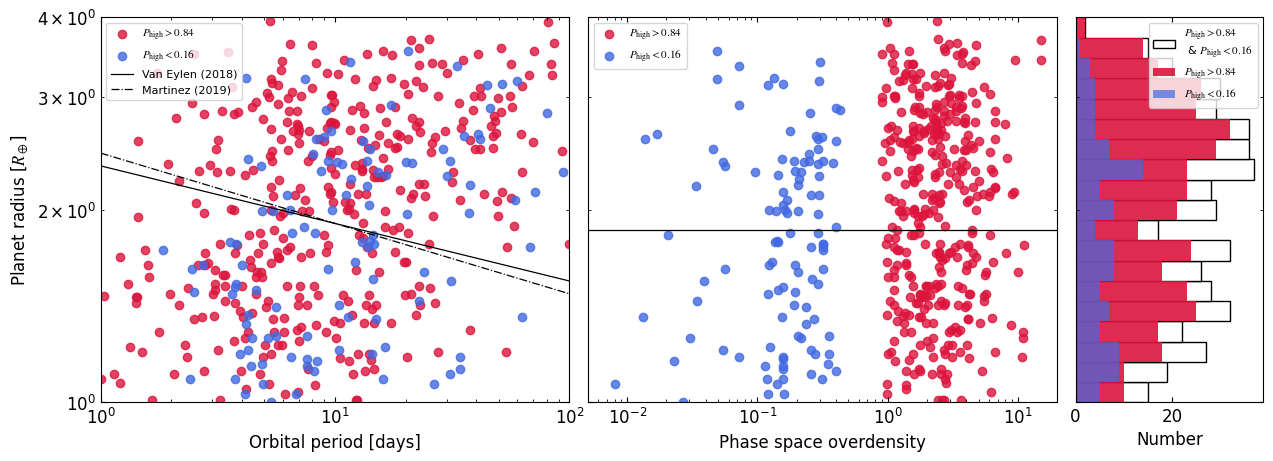

In [19]:
sample_clean.radius_orbitalper_rho()  

In [ ]:
sample_clean.radius_orbitalper_rho_linear()  

In [ ]:
sample_clean.radius_radius_valley_orbital_per_rho()

In [ ]:
sample_clean.radius_valley_histogram_overlap()

In [ ]:
sample_clean.radius_valley_histogram_stacked()

In [ ]:
sample_clean.radius_gaussian_mixture(printing=False)

# Young sample

In [20]:
sample_young.stat_test(stat_test=True)

1.860508094080351


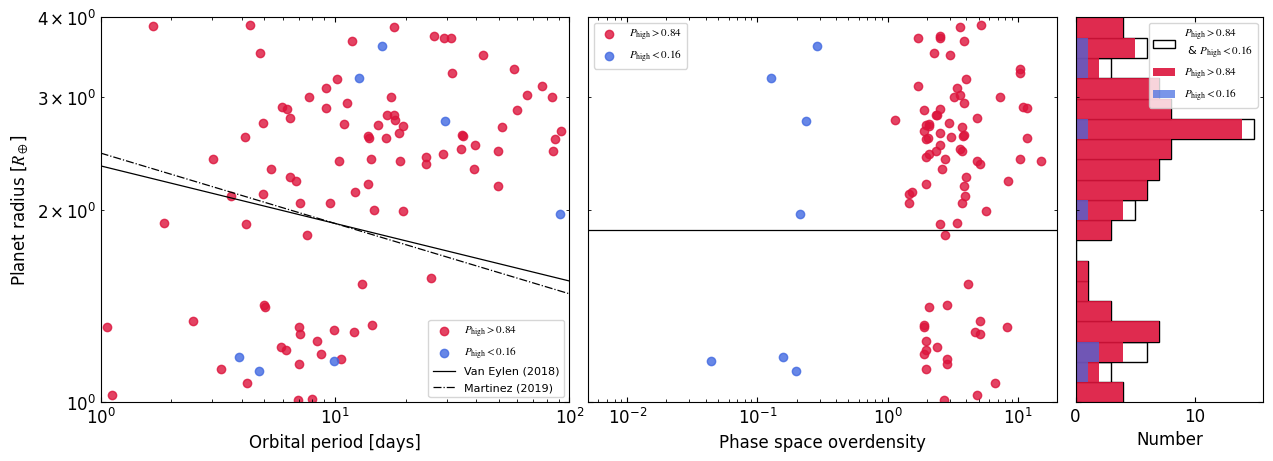

In [21]:
sample_young.radius_orbitalper_rho()  

In [ ]:
sample_young.radius_orbitalper_rho_linear()  

In [ ]:
sample_young.radius_radius_valley_orbital_per_rho()

In [ ]:
sample_young.radius_valley_histogram_overlap()

In [ ]:
sample_young.radius_valley_histogram_stacked()

In [ ]:
sample_young.radius_gaussian_mixture(printing=False)

# Old sample

In [22]:
sample_old.stat_test(stat_test=True)

1.860508094080351


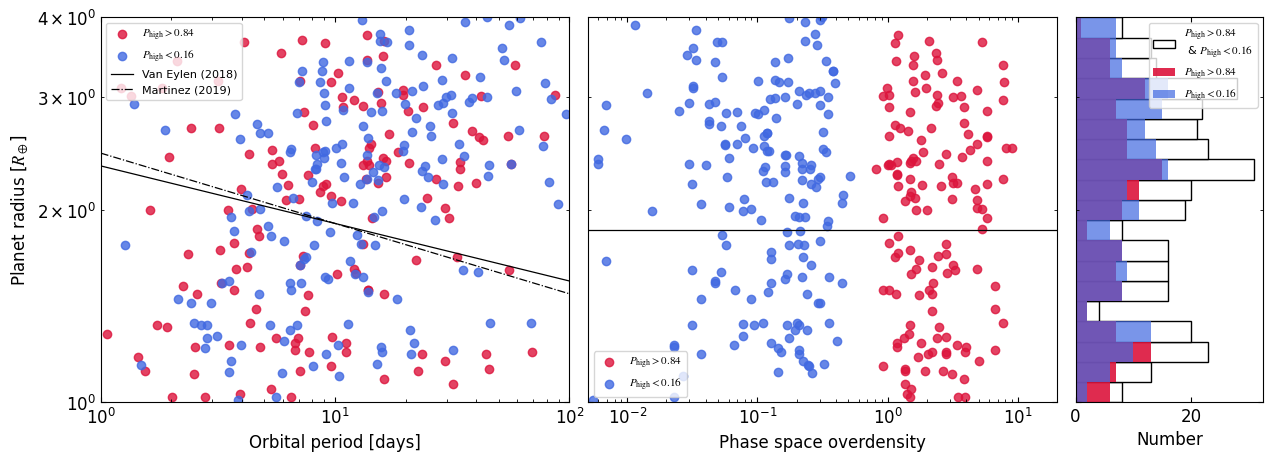

In [23]:
sample_old.radius_orbitalper_rho()  

In [ ]:
sample_old.radius_orbitalper_rho_linear() 

In [ ]:
sample_old.radius_radius_valley_orbital_per_rho()

In [ ]:
sample_old.radius_valley_histogram_overlap()

In [ ]:
sample_old.radius_valley_histogram_stacked()

In [ ]:
sample_old.radius_gaussian_mixture(printing=False)

# Any Age Sample

In [25]:
sample_all_ages.stat_test(stat_test=True)

In [ ]:
sample_all_ages.radius_orbitalper_rho()

# Unfiltered Sample

In [ ]:
sample_unfiltered.stat_test(stat_test=False)

In [ ]:
sample_unfiltered.radius_orbitalper_rho()

# Filtered Sample (old)

In [ ]:
#sample_filtered.radius_orbitalper_rho()

In [ ]:
#sample_filtered.stat_test(stat_test=False)

# Comparison between old and young systems

In [26]:
#Check incidence of super-Earths vs. sub-Neptunes in old vs. young
all_incidence_rho = sample_all_ages.planets_incidence_overdensity_field
incidence_rho = sample_clean.planets_incidence_overdensity_field
young_incidence_rho = sample_young.planets_incidence_overdensity_field
old_incidence_rho = sample_old.planets_incidence_overdensity_field

all_incidence = sample_all_ages.planets_incidence_above_below
incidence = sample_clean.planets_incidence_above_below
young_incidence = sample_young.planets_incidence_above_below
old_incidence = sample_old.planets_incidence_above_below

folder = "comparison/"
if not os.path.exists(folder):
    os.mkdir(folder)
filepath = folder + "stellar_age_comparison_sample_clean_"+ time.strftime("%Y%m%d_%H%M%S") +".txt"

if not os.path.exists(filepath):
    with open(filepath, "w") as file:
        print(f"Incidence of super-Earths vs. sub-Neptunes in systems of any age: {all_incidence}", file=file)
        print(f"Incidence of super-Earths vs. sub-Neptunes in systems of 1 Gyr < age < 4.5 Gyr: {incidence}", file=file)
        print(f"Incidence of super-Earths vs. sub-Neptunes in systems of age <1 Gyr: {young_incidence}", file=file)
        print(f"Incidence of super-Earths vs. sub-Neptunes in systems of age >1 Gyr: {old_incidence}", file=file)
        print("\n", file=file)
        print(f"Incidence of overdensity vs. field in systems of any age: {all_incidence_rho}", file=file)
        print(f"Incidence of overdensity vs. field in systems of 1 Gyr < age < 4.5 Gyr: {incidence_rho}", file=file)
        print(f"Incidence of overdensity vs. field in systems of age <1 Gyr: {young_incidence_rho}", file=file)
        print(f"Incidence of overdensity vs. field in systems of age >1 Gyr: {old_incidence_rho}", file=file)
        
print(f"Incidence of super-Earths vs. sub-Neptunes in systems of any age: {all_incidence}")
print(f"Incidence of super-Earths vs. sub-Neptunes in systems of 1 Gyr < age < 4.5 Gyr: {incidence}")
print(f"Incidence of super-Earths vs. sub-Neptunes in systems of age <1 Gyr: {young_incidence}")
print(f"Incidence of super-Earths vs. sub-Neptunes in systems of age >1 Gyr: {old_incidence}")
print("\n")
print(f"Incidence of overdensity vs. field in systems of any age: {all_incidence_rho}")
print(f"Incidence of overdensity vs. field in systems of 1 Gyr < age < 4.5 Gyr: {incidence_rho}")
print(f"Incidence of overdensity vs. field in systems of age <1 Gyr: {young_incidence_rho}")
print(f"Incidence of overdensity vs. field in systems of age >1 Gyr: {old_incidence_rho}")

Incidence of super-Earths vs. sub-Neptunes in systems of any age: 0.6336779911373708
Incidence of super-Earths vs. sub-Neptunes in systems of 1 Gyr < age < 4.5 Gyr: 0.797752808988764
Incidence of super-Earths vs. sub-Neptunes in systems of age <1 Gyr: 0.36619718309859156
Incidence of super-Earths vs. sub-Neptunes in systems of age >1 Gyr: 0.599009900990099


Incidence of overdensity vs. field in systems of any age: 2.005434782608696
Incidence of overdensity vs. field in systems of 1 Gyr < age < 4.5 Gyr: 3.3636363636363638
Incidence of overdensity vs. field in systems of age <1 Gyr: 12.857142857142858
Incidence of overdensity vs. field in systems of age >1 Gyr: 0.8044692737430168


In [ ]:
#Check metallicity of old vs. young

all_metallicity = np.median(sample_all_ages.filtered_metallicity)
metallicity = np.median(sample_clean.filtered_metallicity)
young_metallicity = np.median(sample_young.filtered_metallicity)
old_metallicity = np.median(sample_old.filtered_metallicity)

folder = "comparison/"
if not os.path.exists(folder):
    os.mkdir(folder)
filepath = folder + "metallicity_comparison_sample_clean_"+ time.strftime("%Y%m%d_%H%M%S") +".txt"

if not os.path.exists(filepath):
    with open(filepath, "w") as file:
        print(f"Median metallicity of stars with any age: {all_metallicity}", file=file)
        print(f"Median metallicity of stars with 1 Gyr < age < 4.5 Gyr: {metallicity}", file=file)
        print(f"Median metallicity of stars with age <1 Gyr: {young_metallicity}", file=file)
        print(f"Median metallicity of stars with age >1 Gyr: {old_metallicity}", file=file)

print(f"Median metallicity of stars with any age: {all_metallicity}")
print(f"Median metallicity of stars with 1 Gyr < age < 4.5 Gyr: {metallicity}")
print(f"Median metallicity of stars with age <1 Gyr: {young_metallicity}")
print(f"Median metallicity of stars with age >1 Gyr: {old_metallicity}")

# Comparison: Field vs. Overdensity

In [30]:
samples = [sample_young, sample_clean, sample_old, sample_all_ages]
sample_names = ['sample_young', 'sample_clean', 'sample_old', 'sample_all_ages']

choice = 4

sample_choice = samples[choice-1]
sample_name = sample_names[choice-1]


field_stellar_mass = np.median(np.array(sample_choice.filtered_stellar_mass_low_rho))
overdensity_stellar_mass = np.median(np.array(sample_choice.filtered_stellar_mass_high_rho))

field_metallicity = np.median(np.array(sample_choice.filtered_metallicity_low_rho))
overdensity_metallicity = np.median(np.array(sample_choice.filtered_metallicity_high_rho))

field_stellar_age = np.median(np.array(sample_choice.filtered_stellar_age_low_rho))
overdensity_stellar_age = np.median(np.array(sample_choice.filtered_stellar_age_high_rho))

field_stellar_dist = np.median(np.array(sample_choice.filtered_stellar_dist_low_rho))
overdensity_stellar_dist = np.median(np.array(sample_choice.filtered_stellar_dist_high_rho))



folder = "comparison/"
if not os.path.exists(folder):
    os.mkdir(folder)
filepath = folder + "comparison_" + sample_name + "_"+ time.strftime("%Y%m%d_%H%M%S") +".txt"


if not os.path.exists(filepath):
    with open(filepath, "w") as f:
        print(f"Median stellar_mass of field systems: {field_stellar_mass}", file=f)
        print(f"Median stellar_mass of overdensity systems: {overdensity_stellar_mass}", file=f)
        print("\n", file=f)
        print(f"Median metallicity of field systems: {field_metallicity}", file=f)
        print(f"Median metallicity of overdensity systems: {overdensity_metallicity}", file=f)
        print("\n", file=f)
        print(f"Median stellar age of field systems: {field_stellar_age}", file=f)
        print(f"Median stellar age of overdensity systems: {overdensity_stellar_age}", file=f)
        print("\n", file=f)
        print(f"Median stellar distance of field systems: {field_stellar_dist}", file=f)
        print(f"Median stellar distance of overdensity systems: {overdensity_stellar_dist}", file=f)
        print("\n", file=f)


print(f"Median stellar_mass of field systems: {field_stellar_mass}")
print(f"Median stellar_mass of overdensity systems: {overdensity_stellar_mass}")
print("\n")
print(f"Median metallicity of field systems: {field_metallicity}")
print(f"Median metallicity of overdensity systems: {overdensity_metallicity}")
print("\n")
print(f"Median stellar age of field systems: {field_stellar_age}")
print(f"Median stellar age of overdensity systems: {overdensity_stellar_age}")
print("\n")
print(f"Median stellar distance of field systems: {field_stellar_dist}")
print(f"Median stellar distance of overdensity systems: {overdensity_stellar_dist}")
print("\n")

Median stellar_mass of field systems: 0.9205730000000001
Median stellar_mass of overdensity systems: 0.9712305


Median metallicity of field systems: -0.01
Median metallicity of overdensity systems: 0.04


Median stellar age of field systems: 5.37
Median stellar age of overdensity systems: 2.9


Median stellar distance of field systems: 401.866
Median stellar distance of overdensity systems: 411.2815




# Stellar and planet properties - 1-4.5 Gyr

In [ ]:
sample_clean.stellar_age_cumulative_hist(lim1=1, lim2=4.5, stepsize=0.00001)

In [ ]:
sample_clean.metallicity_cumulative_hist(stepsize=0.00001)

In [ ]:
sample_clean.stellar_mass_cumulative_hist(lim1=0.7)

In [ ]:
sample_clean.stellar_dist_cumulative_hist()

In [ ]:
sample_clean.planet_radius_cumulative_hist(lim1=1)

In [ ]:
sample_clean.pl_density_cumulative_hist()

In [ ]:
sample_clean.pl_mass_cumulative_hist(lim2=100)

In [ ]:
sample_clean.pl_semimajor_cumulative_hist()

In [ ]:
sample_clean.pl_ecc_cumulative_hist()

In [ ]:
sample_clean.pl_orbper_cumulative_hist(lim1=1, lim2=90)

In [ ]:
sample_clean.stat_test_properties(stat_test_prop=True)

# Stellar and planet properties - unfiltered sample

In [ ]:
sample_unfiltered.stellar_age_cumulative_hist()

In [ ]:
sample_unfiltered.metallicity_cumulative_hist()

In [ ]:
sample_unfiltered.stellar_mass_cumulative_hist()

In [ ]:
sample_unfiltered.stellar_dist_cumulative_hist()

In [ ]:
sample_unfiltered.planet_radius_cumulative_hist()

In [ ]:
sample_unfiltered.pl_density_cumulative_hist()

In [ ]:
sample_unfiltered.pl_mass_cumulative_hist()

In [ ]:
sample_unfiltered.pl_semimajor_cumulative_hist()

In [ ]:
sample_unfiltered.pl_ecc_cumulative_hist()

In [ ]:
sample_unfiltered.pl_orbper_cumulative_hist()

In [ ]:
sample_unfiltered.stat_test_properties(stat_test_prop=True)

# Study of X-Y plot

In [ ]:
sol_sample.X_Y_plot()

In [ ]:
#Study weird pattern in plot

width = 5
dist = 7

start = (-35,68)
end = (0,15)

start = np.array(start)
end = np.array(end)

dir_vec = start - end
dir_vec_norm = dir_vec/(np.linalg.norm(dir_vec))

normal_vec = np.array([dir_vec_norm[1], -dir_vec_norm[0]])

halfwidth = width/2 * normal_vec
fullwidth = width * normal_vec

distance = dist * normal_vec

band_pos = [start - halfwidth, start + halfwidth, end + halfwidth, end - halfwidth]
outside_band_pos = [start - halfwidth - distance - fullwidth, start - halfwidth - distance, end - halfwidth - distance, end - halfwidth - distance - fullwidth]

sol_sample.study_pattern(band_pos, outside_band_pos)

In [ ]:
rho_inside = sol_sample.rho_band

plt.figure()
plt.hist(np.log10(rho_inside), bins=20)


In [ ]:
rho_outside = sol_sample.rho_outside_band

plt.figure()
plt.hist(np.log10(rho_outside), bins=20)